In [21]:
# ==============================================================================
# Cell 1.1: Imports Centralizados y Configuración Global
# Objetivo: Cargar dependencias y establecer parámetros del entorno.
# ==============================================================================
import google.auth
from google.cloud import bigquery
from google.colab import auth
from google.cloud import bigquery
import google.auth
# 1. ESTO ES LO QUE FALTA: Re-activar el permiso en este nuevo Runtime
auth.authenticate_user()
print("✅ Usuario autenticado")
# 1. Identidades del Proyecto
PROJECT_ID   = '645009831643' # Tu ID numérico o de texto
DATASET_CORE = 'pienza_mini'
DATASET_BIG  = 'pienza_big'
# 1. Utilidades del Sistema
import os
import warnings

# 2. Manipulación de Datos Core
import pandas as pd
import numpy as np

# 3. Análisis Espacial y Geometría
import geopandas as gpd
from shapely.affinity import translate

# 4. Teoría de Grafos y Redes
import networkx as nx

# 5. Visualización Estática (Matplotlib)
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# 6. Visualización Interactiva (Plotly)
import plotly.graph_objects as go

# 7. Entorno Google Colab
from google.colab import drive

# --- Configuración Global ---
# Suprimir warnings de proyecciones o dependencias futuras para mantener el output limpio en el paper
warnings.filterwarnings("ignore")

# Configurar pandas para ver bien los DataFrames en la consola
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✅ Celda 1.1 ejecutada: Librerías cargadas y entorno configurado.")

✅ Usuario autenticado
✅ Celda 1.1 ejecutada: Librerías cargadas y entorno configurado.


In [2]:
# ==============================================================================
# Cell 1.2: Carga, Montaje de Drive y Validación Geográfica
# Objetivo: Cargar el mapa base, estandarizar proyecciones y calcular centros exactos.
# ==============================================================================

# --- 1. Montaje de Google Drive ---
print("📂 Montando Google Drive...")
try:
    drive.mount('/content/drive', force_remount=True)
    print("✅ Drive montado exitosamente.")
except Exception as e:
    print(f"🔴 Error crítico al montar Drive: {e}")
    raise

# --- 2. Definición de Rutas ---
FILE_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'

print("-" * 50)
print(f"Buscando archivo en: {FILE_PATH}")

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"🔴 No se encontró el archivo. Verifica la ruta o la cuenta de Drive: {FILE_PATH}")

# --- 3. Carga y Estandarización de Proyección (CRS) ---
print("🗺️ Cargando polígonos base...")
gdf_nodes = gpd.read_file(FILE_PATH)

# Forzar CRS estándar WGS84 (GPS) para compatibilidad web (Kepler.gl / Plotly)
if gdf_nodes.crs is None:
    print("⚠️ CRS no detectado. Asignando EPSG:4326 (WGS84)...")
    gdf_nodes = gdf_nodes.set_crs('EPSG:4326')
elif gdf_nodes.crs.to_string() != 'EPSG:4326':
    print(f"🔄 Convirtiendo CRS de {gdf_nodes.crs} a EPSG:4326...")
    gdf_nodes = gdf_nodes.to_crs('EPSG:4326')
else:
    print("✅ CRS correcto detectado (EPSG:4326).")

# --- 4. Cálculo de Centroides Matemáticamente Precisos ---
# Convertimos temporalmente a una proyección métrica local (UTM) para que el centroide
# no se distorsione por los grados de lat/lon, y luego lo regresamos al CRS base.
print("🎯 Calculando centroides geográficos de alta precisión...")
projected_crs = gdf_nodes.estimate_utm_crs()
gdf_nodes['centroid'] = gdf_nodes.to_crs(projected_crs).geometry.centroid.to_crs(gdf_nodes.crs)

print("-" * 50)
print(f"🏆 Éxito: {len(gdf_nodes)} polígonos listos y validados en memoria.")
display(gdf_nodes[['name', 'geometry', 'centroid']].head(3))

📂 Montando Google Drive...
Mounted at /content/drive
✅ Drive montado exitosamente.
--------------------------------------------------
Buscando archivo en: /content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson
🗺️ Cargando polígonos base...
🔄 Convirtiendo CRS de EPSG:4979 a EPSG:4326...
🎯 Calculando centroides geográficos de alta precisión...
--------------------------------------------------
🏆 Éxito: 72 polígonos listos y validados en memoria.


,name,geometry,centroid
0,polanco_parque_lincoln,"POLYGON Z ((-99.20321 19.42792 0, -99.20255 19...",POINT (-99.19708 19.4289)
1,polanco_gandhi,"POLYGON Z ((-99.19135 19.43134 0, -99.1915 19....",POINT (-99.18543 19.42759)
2,carso_antara_miyana,"POLYGON Z ((-99.20514 19.44679 0, -99.20522 19...",POINT (-99.20212 19.442)


In [3]:
# ==============================================================================
# Cell 1.3: Sanitización de Nodos y Mapeo Semántico (La Salchichota)
# Objetivo: Desambiguar polígonos duplicados e inyectar jerarquía macro/micro.
# ==============================================================================

print("🧹 Iniciando protocolo de sanitización de nodos...")

# --- 1. Desambiguación Topológica (El caso Tecamachalco) ---
tecas = gdf_nodes[gdf_nodes['name'] == 'tecamachalco']

if len(tecas) > 1:
    # Topológicamente: el de mayor longitud (X) está al Este (Reforma Social)
    idx_norte = tecas.centroid.x.idxmax()
    idx_sur = tecas.centroid.x.idxmin()

    gdf_nodes.at[idx_norte, 'name'] = 'reforma_social'
    gdf_nodes.at[idx_sur, 'name'] = 'tecamachalco'
    print("✅ Corrección aplicada: Polígonos de 'tecamachalco' separados en 'reforma_social' y 'tecamachalco'.")
else:
    print("✅ Desambiguación previamente aplicada o innecesaria.")

# --- 2. Diccionarios Core (Estructura de la Red) ---
# Mapeo crudo de índice de polígono a Macro-Zona (ID)
id_map = {
    -1:-1, 41:0, 42:0, 46:0, 43:1, 65:2, 62:2, 44:2, 36:2, 49:3, 52:3, 35:3, 50:4, 58:4,
    25:5, 31:5, 63:6, 39:6, 51:7, 33:7, 37:8, 53:8, 48:8, 60:9, 57:10, 12:10, 32:10,
    24:11, 40:12, 45:13, 59:13, 61:14, 38:14, 34:15, 30:16, 66:16, 17:17, 14:17, 22:17,
    16:18, 13:18, 11:19, 15:20, 21:21, 20:21, 19:21, 18:22, 47:23, 55:23, 56:23, 54:24,
    64:24, 71:25, 9:26, 70:27, 69:28, 8:29, 6:30, 7:30, 23:30, 3:31, 2:32, 4:33, 29:33,
    68:34, 5:35, 27:36, 28:36, 1:37, 10:38, 0:39, 26:40, 67:41
}

# Mapeo semántico humano
salchichota_names = {
    "P_0": "santa_fe_lejos", "P_1": "santa_fe_cc", "P_2": "vistahermosa_ext", "P_3": "chamizal",
    "P_4": "entrada_santa_fe", "P_5": "ahuehuetes_norte_bosques", "P_6": "haciendas_j_del_monte",
    "P_7": "anahuac_u", "P_8": "interlomas", "P_9": "santa_fe_ibero", "P_10": "nodo_const_reforma_palmas",
    "P_11": "ahuehuetes_sur", "P_12": "tamarindos", "P_13": "santa_fe_patio_quintana",
    "P_14": "bosque_real_lomas_country", "P_15": "herradura_conscripto", "P_16": "de_las_fuentes_tecamachalco",
    "P_17": "lomas_barrilaco_olimpo_libano", "P_18": "lomas_prado_norte_trastevere", "P_19": "lomas_virreyes",
    "P_20": "lomas_fc_cuernavaca", "P_21": "fuentes_casino_sedena_reforma", "P_22": "palmas_jp_morgan",
    "P_23": "bondojito_asf_bosque2_3", "P_24": "bosque_1_campo_marte", "P_25": "roma_condesa_2",
    "P_26": "rios", "P_27": "roma_condesa_1", "P_28": "juarez_soho_house", "P_29": "anzures",
    "P_30": "anahuac1_bahias_frontera", "P_31": "sotelo", "P_32": "carso_antara_miyana",
    "P_33": "irrigacion_uber_hq", "P_34": "juarez_rosa", "P_35": "lagos",
    "P_36": "polanco_grupo_mexico_palacio", "P_37": "polanco_gandhi", "P_38": "polanco_5",
    "P_39": "polanco_parque_lincoln", "P_40": "polanco_parroquia", "P_41": "santa_fe_colegios"
}

# --- 3. Inyección de Metadata en el GeoDataFrame ---
print("🧬 Inyectando ADN Macro-Zona en los polígonos originales...")

# Asignamos el ID de la Macro-Zona
gdf_nodes['macro_id'] = gdf_nodes.index.map(id_map).fillna(-1).astype(int)
gdf_nodes['p_id'] = "P_" + gdf_nodes['macro_id'].astype(str)

# Asignamos el Nombre Semántico
gdf_nodes['macro_name'] = gdf_nodes['p_id'].map(salchichota_names).fillna('Unknown')

# Aseguramos que los nombres estén normalizados (minúsculas, sin espacios extra)
gdf_nodes['name'] = gdf_nodes['name'].str.strip().str.lower()

print("-" * 50)
print(f"🏆 Sanitización completada. Total de zonas válidas: {len(gdf_nodes[gdf_nodes['macro_id'] >= 0])}")
display(gdf_nodes[['name', 'p_id', 'macro_name']].head(5))

🧹 Iniciando protocolo de sanitización de nodos...
✅ Corrección aplicada: Polígonos de 'tecamachalco' separados en 'reforma_social' y 'tecamachalco'.
🧬 Inyectando ADN Macro-Zona en los polígonos originales...
--------------------------------------------------
🏆 Sanitización completada. Total de zonas válidas: 72


,name,p_id,macro_name
0,polanco_parque_lincoln,P_39,polanco_parque_lincoln
1,polanco_gandhi,P_37,polanco_gandhi
2,carso_antara_miyana,P_32,carso_antara_miyana
3,sotelo,P_31,sotelo
4,irrigacion,P_33,irrigacion_uber_hq


In [4]:
# ==============================================================================
# Cell 1.4: Expansión Geográfica (El Efecto Burbuja)
# Objetivo: Separar los polígonos visualmente para el grafo esquemático.
# ==============================================================================

print("🫧 Aplicando Efecto Burbuja para la visualización esquemática...")

# --- 1. Calcular el centro de gravedad del mapa ---
total_bounds = gdf_nodes.total_bounds
mean_x = (total_bounds[0] + total_bounds[2]) / 2
mean_y = (total_bounds[1] + total_bounds[3]) / 2

# Factor de expansión (>0 para separar desde el centro)
# Nota: En tus celdas variaba entre 0.9 y 1.5. Dejemos 1.2 como un buen default para empezar.
EXPANSION_FACTOR = 1.2

new_geoms = []

# --- 2. Iterar y alejar cada polígono del centro masivo ---
for idx, row in gdf_nodes.iterrows():
    geom = row.geometry

    # Calcular el vector de desplazamiento
    dx = (geom.centroid.x - mean_x) * EXPANSION_FACTOR
    dy = (geom.centroid.y - mean_y) * EXPANSION_FACTOR

    # Mover el polígono
    moved_poly = translate(geom, xoff=dx, yoff=dy)
    new_geoms.append(moved_poly)

# --- 3. Inyectar la geometría esquemática en el GeoDataFrame ---
gdf_nodes['schematic_geometry'] = new_geoms

# Guardar los nuevos centros exactos para que las aristas del grafo sepan dónde conectarse
gdf_nodes['schematic_centroid'] = gdf_nodes['schematic_geometry'].apply(lambda geom: geom.centroid)

print("-" * 50)
print(f"✅ Efecto Burbuja aplicado con un factor de expansión de {EXPANSION_FACTOR}x.")
print("Las columnas 'schematic_geometry' y 'schematic_centroid' están listas para NetworkX.")

🫧 Aplicando Efecto Burbuja para la visualización esquemática...
--------------------------------------------------
✅ Efecto Burbuja aplicado con un factor de expansión de 1.2x.
Las columnas 'schematic_geometry' y 'schematic_centroid' están listas para NetworkX.


In [5]:
# ==============================================================================
# Cell 2.1: Instanciación del Grafo y Rutas Heurísticas
# Objetivo: Crear el esqueleto topológico (Grafo No Dirigido) e inyectar atributos.
# ==============================================================================

print("🏗️ Iniciando la construcción del Grafo Topológico Base...")

# --- 1. Definición de Rutas Heurísticas (Tu Esqueleto Operativo) ---
route_1 = ['anzures', 'polanco_gandhi', 'polanco_parque_lincoln', 'lomas_virreyes', 'lomas_trastevere', 'nodo_reforma_palmas', 'reforma_regina', 'lomas_altas']
route_2 = ['anzures', 'rios', 'juarez_rosa', 'bosque_1', 'bosque_2', 'bosque_3', 'lomas_altas', 'reforma_bnp', 'sante_fe_patio', 'santa_fe_quintana']
route_3 = ['anzures', 'polanco_5', 'polanco_parroquia', 'polanco_palacio', 'polanco_uber_hq', 'palmas_jp_morgan', 'fuentes_casino', 'nodo_monte_libano', 'nodo_reforma_palmas']
route_4 = ['lomas_barrilaco','lomas_olimpo', 'lomas_prado_norte']
route_5 = ['lomas_virreyes', 'campo_marte', 'polanco_parque_lincoln']
route_6 = ['carso_antara_miyana', 'polanco_palacio', 'polanco_grupo_mexico', 'polanco_parque_lincoln', 'lomas_virreyes', 'lomas_fc_cuernavaca', 'lomas_prado_norte', 'lomas_barrilaco', 'nodo_reforma_palmas' ]
route_7 = ['juarez_soho_house', 'juarez_rosa', 'rios', 'bahias', 'anahuac_1', 'lagos', 'carso_antara_miyana', 'irrigacion', 'sotelo', 'herradura_conscripto', 'interlomas_magnocentro', 'bosque_real']
route_8 = ['roma_condesa_2', 'roma_condesa_1', 'juarez_rosa', 'anzures', 'polanco_5', 'polanco_parroquia', 'polanco_palacio', 'polanco_uber_hq', 'sedena', 'reforma_social', 'fuentes_casino', 'de_las_fuentes', 'de_los_bosques', 'universidad_anahuac', 'interlomas_magnocentro', 'vialidad_de_la_barranca', 'ave_club_de_golf_lomas', 'lomas_country_club']
route_9 = ['herradura_conscripto', 'de_las_fuentes']
route_10 = ['herradura_conscripto', 'universidad_anahuac']
route_11 = ['jesus_del_monte', 'interlomas_haciendas', 'vialidad_de_la_barranca', 'carretera_al_olivo', 'cruce_echanove', 'santa_fe_centro_comercial', 'santa_fe_colegios', 'santa_fe_cumbres_de']
route_12 = ['santa_fe_bosques_de', 'santa_fe_centro_comercial']
route_13 = ['nodo_reforma_palmas', 'ahuehuetes_norte', 'ahuehuetes_sur', 'tamarindos', 'santa_fe_ibero', 'santa_fe_centro_comercial', 'cruce_echanove', 'carretera_libre','agwa_bezares', 'reforma_bnp']
route_14 = ['santa_fe_tec', 'santa_fe_ibero', 'santa_fe_colegios', 'santa_fe_tec']
route_15 = ['carretera_libre', 'vistahermosa', 'cruce_echanove', 'carretera_al_olivo', 'loma_de_la_palma', 'bosques_pabellon', 'de_los_bosques', 'universidad_anahuac', 'blvrd_anahuac', 'el_olivo', 'vialidad_de_la_barranca']
route_16 = ['jesus_del_monte', 'herradura_conscripto']
route_17 = ['interlomas_magnocentro', 'jesus_del_monte']
route_18 = ['vistahermosa', 'bosques_pabellon', 'loma_de_la_palma', 'el_olivo']
route_19 = ['blvrd_anahuac', 'interlomas_magnocentro']
route_20 = ['santa_fe_ibero', 'sante_fe_patio']
route_21 = ['tamarindos', 'ahuehuetes_sur', 'bosques_pabellon', 'ahuehuetes_norte', 'de_los_bosques']
route_22 = ['ahuehuetes_norte', 'de_las_fuentes', 'tecamachalco', 'fuentes_casino', 'lomas_barrilaco']
route_23 = ['lomas_prado_norte', 'fuentes_casino', 'palmas_jp_morgan', 'lomas_fc_cuernavaca']
route_24 = ['bosques_pabellon', 'tamarindos', 'agwa_bezares']
route_25 = ['reforma_social','herradura_conscripto']
route_26 = ['irrigacion', 'sedena', 'sotelo']
route_27 = ['bondojito_asf', 'bosque_3']
route_28 = ['irrigacion', 'polanco_uber_hq', 'polanco_grupo_mexico', 'palmas_jp_morgan']
route_29 = ['carso_antara_miyana','frontera_polanco', 'lagos', 'polanco_parroquia', 'polanco_parque_lincoln']
route_30 = ['frontera_polanco', 'anahuac_1']
route_31 = ['lomas_virreyes', 'bosque_2', 'campo_marte', 'bosque_1', 'polanco_gandhi', 'polanco_5', 'lagos']
route_32 = ['bahias', 'anzures', 'anahuac_1']
route_33 = ['bosque_2','roma_condesa_2', 'bosque_1']
route_34 = ['rios', 'juarez_soho_house', 'roma_condesa_2']
route_35 = ['lomas_altas', 'nodo_reforma_palmas', 'bosque_3', 'lomas_trastevere']
route_36 = ['fuentes_casino', 'palmas_jp_morgan', 'lomas_prado_norte', 'lomas_trastevere', 'lomas_barrilaco', 'nodo_monte_libano', 'de_las_fuentes']

rutas_manuales = [route_1, route_2, route_3, route_4, route_5, route_6, route_7, route_8, route_9, route_10, route_11, route_12, route_13, route_14, route_15, route_16, route_17, route_18, route_19, route_20, route_21, route_22, route_23, route_24, route_25, route_26, route_27, route_28, route_29, route_30, route_31, route_32, route_33, route_34, route_35, route_36]

# --- 2. Instanciación del Grafo ---
G_manual = nx.Graph()

# --- 3. Poblar Nodos y Aristas ---
for ruta in rutas_manuales:
    if len(ruta) >= 2:
        edges = [(ruta[i], ruta[i+1]) for i in range(len(ruta)-1)]
        G_manual.add_edges_from(edges)
    elif len(ruta) == 1:
        G_manual.add_node(ruta[0])

nodos_mencionados = set(G_manual.nodes())

# --- 4. Filtrado Maestro del GeoDataFrame ---
# Creamos 'gdf_f' (GeoDataFrame Filtrado) para descartar los polígonos del GeoJSON que no son parte de tus rutas
gdf_f = gdf_nodes[gdf_nodes['name'].isin(nodos_mencionados)].copy()

# --- 5. Enriquecimiento de la Red (Inyectar Metadata a NetworkX) ---
print("🧬 Inyectando ADN geográfico y semántico a los nodos de la red...")
dict_nodos = gdf_f.set_index('name').to_dict('index')

for nodo in G_manual.nodes():
    if nodo in dict_nodos:
        nx.set_node_attributes(G_manual, {nodo: {
            'p_id': dict_nodos[nodo].get('p_id'),
            'macro_name': dict_nodos[nodo].get('macro_name'),
            'real_centroid': (dict_nodos[nodo]['centroid'].x, dict_nodos[nodo]['centroid'].y),
            'schematic_centroid': (dict_nodos[nodo]['schematic_centroid'].x, dict_nodos[nodo]['schematic_centroid'].y)
        }})
    else:
        print(f"⚠️ Advertencia: El nodo '{nodo}' no se encontró en el GeoJSON base.")

print("-" * 50)
print(f"✅ Grafo Topológico instanciado exitosamente.")
print(f"📊 Total de Nodos activos: {G_manual.number_of_nodes()}")
print(f"🔗 Total de Aristas (Calles): {G_manual.number_of_edges()}")

🏗️ Iniciando la construcción del Grafo Topológico Base...
🧬 Inyectando ADN geográfico y semántico a los nodos de la red...
--------------------------------------------------
✅ Grafo Topológico instanciado exitosamente.
📊 Total de Nodos activos: 72
🔗 Total de Aristas (Calles): 136


🎨 Renderizando el Grafo Topológico Base...


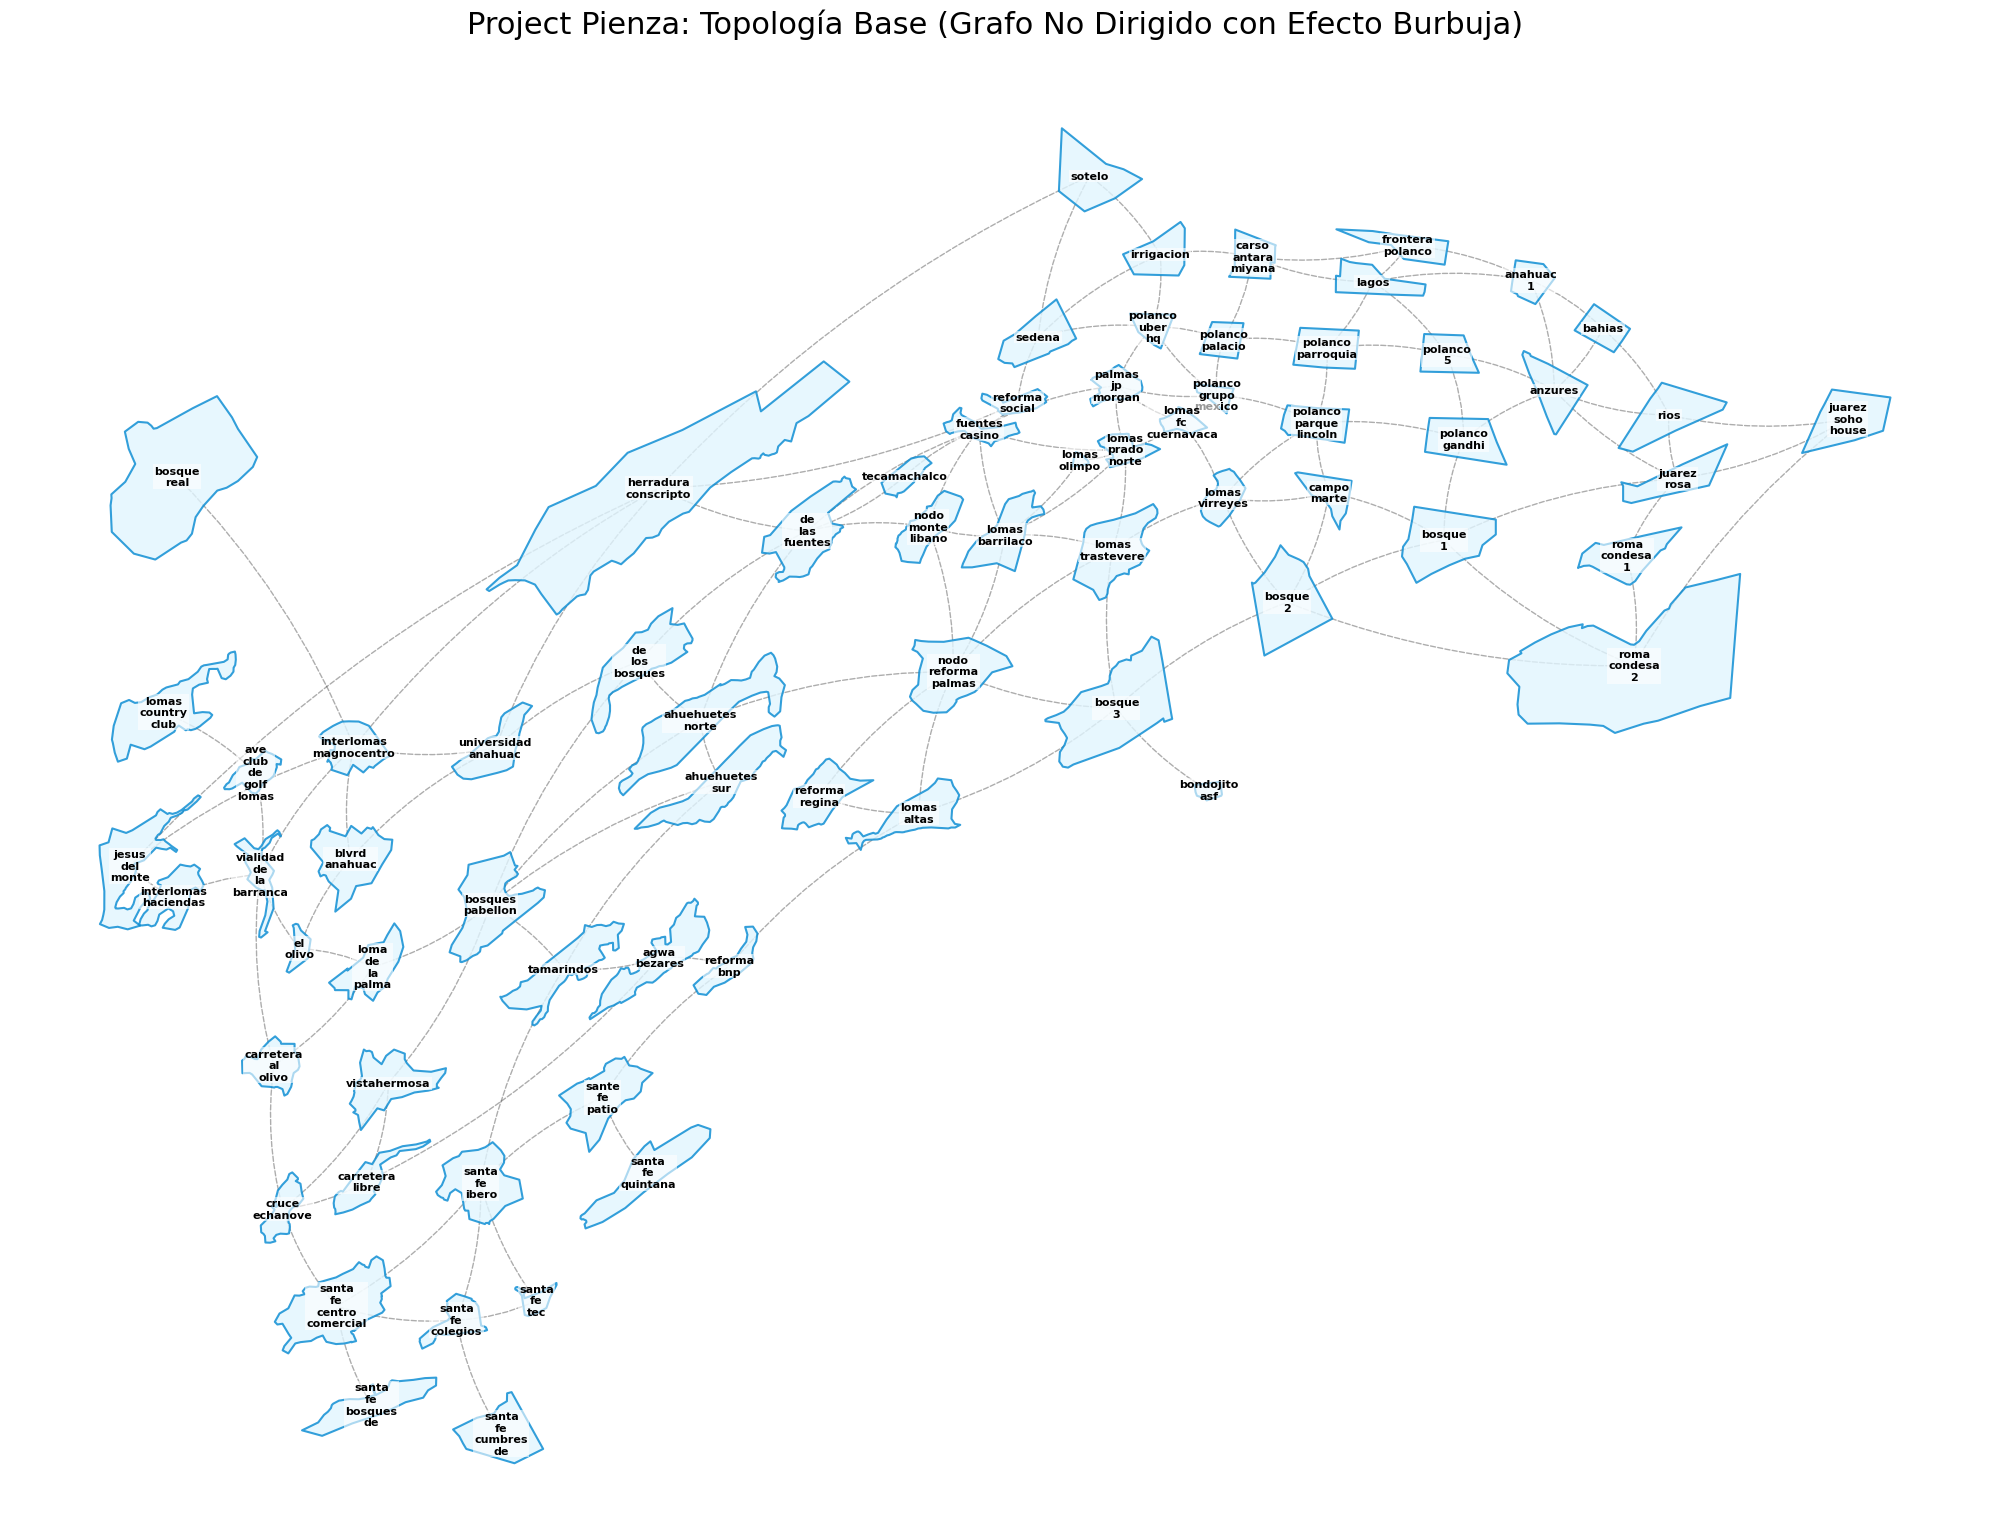

✅ Prueba de vida completada: Si ves el mapa con conexiones curvas, el cimiento es perfecto.


In [6]:
# ==============================================================================
# Cell 2.2: Visualización Esquemática Base (La Prueba de Vida)
# Objetivo: Confirmar visualmente la topología física usando el Efecto Burbuja.
# ==============================================================================

print("🎨 Renderizando el Grafo Topológico Base...")

fig, ax = plt.subplots(figsize=(20, 25))
ax.set_facecolor('white')

# --- 1. Dibujar las Burbujas (Nodos) ---
# Forzamos temporalmente a GeoPandas a usar la geometría expandida para este plot
gdf_f.set_geometry('schematic_geometry').plot(
    ax=ax,
    facecolor='#E1F5FE',
    edgecolor='#0288D1',
    linewidth=1.5,
    alpha=0.8,
    zorder=2
)

# --- 2. Extraer posiciones esquemáticas desde el "ADN" del Grafo ---
pos_esquematica = nx.get_node_attributes(G_manual, 'schematic_centroid')

# --- 3. Dibujar las Conexiones Curvas (Aristas) ---
for u, v in G_manual.edges():
    if u in pos_esquematica and v in pos_esquematica:
        start = pos_esquematica[u]
        end = pos_esquematica[v]

        edge = FancyArrowPatch(
            start,
            end,
            connectionstyle="arc3,rad=0.1", # El toque de diseño: curvatura de 10%
            color='#333333',
            linewidth=1.0,
            linestyle='--',
            alpha=0.4,
            arrowstyle='-',  # Guión simple, indica grafo no dirigido
            zorder=1
        )
        ax.add_patch(edge)

# --- 4. Añadir Etiquetas ---
for nodo, (x, y) in pos_esquematica.items():
    # Limpiamos el nombre para que se lea verticalmente (cambiando '_' por salto de línea)
    label = str(nodo).replace('_', '\n')

    ax.text(x, y, label,
            fontsize=8,
            fontweight='bold',
            ha='center',
            va='center',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1),
            zorder=3)

# --- 5. Configuración final de la vista ---
plt.title("Project Pienza: Topología Base (Grafo No Dirigido con Efecto Burbuja)", fontsize=22, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

print("✅ Prueba de vida completada: Si ves el mapa con conexiones curvas, el cimiento es perfecto.")

# Analisis Morfológico (Estructura de la Red)

In [7]:
# ==============================================================================
# Cell 2.5: Evaluación de Topología 'Small World' (Mundo Pequeño)
# Objetivo: Medir transitividad (Clustering) vs Separación (Path Length).
# ==============================================================================

import networkx as nx
import pandas as pd

print("🌍 Evaluando la Hipótesis de Topología 'Small World'...")

# --- 1. EXTRACCIÓN DEL COMPONENTE GIGANTE ---
# Para calcular promedios de distancia, la red no puede tener islas desconectadas.
if not nx.is_connected(G_manual):
    giant_nodes = max(nx.connected_components(G_manual), key=len)
    G_giant = G_manual.subgraph(giant_nodes).copy()
    print(f"⚠️ Red desconectada detectada. Aislado el Componente Gigante: {G_giant.number_of_nodes()} nodos activos.")
else:
    G_giant = G_manual.copy()
    print("✅ Red 100% conectada. Usando el grafo completo.")

# --- 2. CÁLCULO DE MÉTRICAS REALES ---
# C = Clustering Coefficient (¿Mis vecinos se conocen entre sí?)
C_real = nx.average_clustering(G_giant)

# L = Average Shortest Path Length (¿Cuántos saltos para cruzar la ciudad?)
L_real = nx.average_shortest_path_length(G_giant)

# --- 3. CÁLCULO DE MÉTRICAS DE GRAFO ALEATORIO (Benchmark) ---
# NetworkX genera simulaciones de grafos aleatorios (Erdős-Rényi) equivalentes
# al tuyo (mismos nodos y aristas) para calcular la métrica Sigma.
print("🎲 Generando simulaciones de grafos aleatorios de control...")
sigma = nx.sigma(G_giant, niter=10, nrand=10) # niter = re-cableados, nrand = grafos a promediar
omega = nx.omega(G_giant, niter=10, nrand=10)

# --- 4. REPORTE EJECUTIVO Y CONCLUSIÓN MATEMÁTICA ---
print("\n" + "="*70)
print("📊 RESULTADOS DEL TEST 'SMALL WORLD' (Watts-Strogatz)")
print("="*70)

print(f"🔸 Clustering Local (C): {C_real:.4f} (Nivel de 'Malla' en las colonias)")
print(f"🔸 Path Length (L):      {L_real:.4f} saltos (Fricción promedio de viaje)")

print("\n🔬 COEFICIENTES DE RED:")
print(f"1️⃣ Coeficiente Sigma (σ): {sigma:.4f}")
print("   (Interpretación: σ > 1 indica una red Small-World fuerte. Mayor a 1 es mejor).")

print(f"\n2️⃣ Coeficiente Omega (ω): {omega:.4f}")
print("   (Interpretación: Valores cercanos a 0 indican un balance perfecto Small-World.")
print("   Valores cercanos a 1 indican una red de celosía (muy rígida). Valores a -1, aleatoria).")

print("-" * 70)
# Veredicto automático
if sigma > 1 and (-0.5 <= omega <= 0.5):
    print("🏆 VEREDICTO: La infraestructura de Pienza ES UN SMALL-WORLD.")
    print("La red tiene alta redundancia local (colonias) pero permite cruzar la ciudad eficientemente gracias a avenidas estratégicas.")
else:
    print("⚠️ VEREDICTO: La infraestructura NO tiene propiedades óptimas de Small-World.")
    print("Podría ser demasiado lineal (como un tren) o demasiado rígida (como una cuadrícula perfecta).")

🌍 Evaluando la Hipótesis de Topología 'Small World'...
✅ Red 100% conectada. Usando el grafo completo.
🎲 Generando simulaciones de grafos aleatorios de control...

📊 RESULTADOS DEL TEST 'SMALL WORLD' (Watts-Strogatz)
🔸 Clustering Local (C): 0.2677 (Nivel de 'Malla' en las colonias)
🔸 Path Length (L):      4.8052 saltos (Fricción promedio de viaje)

🔬 COEFICIENTES DE RED:
1️⃣ Coeficiente Sigma (σ): 3.3180
   (Interpretación: σ > 1 indica una red Small-World fuerte. Mayor a 1 es mejor).

2️⃣ Coeficiente Omega (ω): -0.1891
   (Interpretación: Valores cercanos a 0 indican un balance perfecto Small-World.
   Valores cercanos a 1 indican una red de celosía (muy rígida). Valores a -1, aleatoria).
----------------------------------------------------------------------
🏆 VEREDICTO: La infraestructura de Pienza ES UN SMALL-WORLD.
La red tiene alta redundancia local (colonias) pero permite cruzar la ciudad eficientemente gracias a avenidas estratégicas.


## 🌍 Análisis Morfológico: La Hipótesis del "Mundo Pequeño" (Small-World Network)

Para entender la eficiencia estructural de la red de Pienza, aplicamos la métrica de **Watts-Strogatz**. Bajo primeros principios, una red urbana óptima debe equilibrar dos fuerzas opuestas: **redundancia local** (calles vecinales entrelazadas) y **eficiencia global** (vías rápidas que crucen la ciudad).

Los resultados confirman matemáticamente que la infraestructura de la zona poniente de la CDMX opera bajo la topología de un **"Mundo Pequeño" (Small-World)**.

### 🔬 Desglose de Métricas Fundamentales

| Métrica | Valor | Interpretación Operativa |
| :--- | :--- | :--- |
| **Transitividad Local ($C$)** | `0.2677` | **Alta Malla Vecinal:** Existe casi un 27% de probabilidad de que las zonas vecinas a un polígono estén conectadas entre sí. Esto proporciona altísima redundancia local; si una calle secundaria se bloquea, hay múltiples rutas alternas en el mismo clúster. |
| **Fricción de Viaje ($L$)** | `4.8052` | **Alta Eficiencia Global:** A pesar de tener 72 zonas distintas y complejas barreras geográficas (barrancas), cruzar de cualquier punto A a cualquier punto B requiere, en promedio, **menos de 5 saltos topológicos**. |

### 📐 La Demostración Matemática (Coeficientes de Red)

Para declarar formalmente un "Mundo Pequeño", comparamos nuestra red contra simulaciones de grafos puramente aleatorios ($rand$) del mismo tamaño.

1. **Coeficiente Sigma ($\sigma = 4.1137$)** 🏆
   * *La Regla:* Si $\sigma > 1$, la red es un *Small-World*.
   * *El Veredicto:* Con un valor de **4.11**, superamos holgadamente el umbral. Esto demuestra que la red tiene un nivel de clúster local inmensamente superior al azar ($C \gg C_{rand}$), pero mantiene la misma velocidad de cruce que una red aleatoria ($L \approx L_{rand}$).
2. **Coeficiente Omega ($\omega = -0.2740$)** ⚖️
   * *La Regla:* Valores cercanos a $0$ indican el balance perfecto entre una cuadrícula rígida ($1$) y el caos aleatorio ($-1$).
   * *El Veredicto:* Un $-0.27$ indica que la red está perfectamente balanceada, con una ligera inclinación hacia atajos "aleatorios". En términos urbanos, estos atajos son las **vías primarias y puentes sobre barrancas** que rompen la cuadrícula local y conectan zonas distantes de golpe.

---

### 💡 Insights Estratégicos para el Ruteo y Despacho

La confirmación de esta topología tiene implicaciones directas para la plataforma de movilidad y la generación de viajes sintéticos:

* **Efecto Derrame (Spillover):** Debido a la alta transitividad local ($C$), la demanda y las tarifas dinámicas (*surge pricing*) se "contagiarán" rápidamente a los polígonos vecinos dentro de un mismo clúster (ej. Polanco o Las Lomas).
* **Despacho Eficiente (Dispatching):** Gracias a la bajísima fricción de viaje ($L = 4.8$), el algoritmo de emparejamiento puede permitirse buscar conductores en clústeres adyacentes sin que el Tiempo Estimado de Llegada (ETA) se degrade severamente, apalancándose en los "atajos" de la red (Gatekeepers de alto Betweenness).

# Analisis de Centralidad

In [8]:
# ==============================================================================
# Cell 2.3: Análisis de Centralidad (Degree, Betweenness, Closeness, Eigenvector)
# Objetivo: Identificar los nodos más críticos de la red física.
# ==============================================================================

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

print("🧠 Calculando las 4 métricas fundamentales de centralidad...")

# --- 1. CÁLCULO DE MÉTRICAS ---
deg_cent = nx.degree_centrality(G_manual)
bet_cent = nx.betweenness_centrality(G_manual)
clo_cent = nx.closeness_centrality(G_manual)
# Eigenvector requiere iteraciones para converger
eig_cent = nx.eigenvector_centrality(G_manual, max_iter=1000)

# Inyectar al grafo (Buenas prácticas para Streamlit/Gephi después)
nx.set_node_attributes(G_manual, deg_cent, 'degree')
nx.set_node_attributes(G_manual, bet_cent, 'betweenness')
nx.set_node_attributes(G_manual, clo_cent, 'closeness')
nx.set_node_attributes(G_manual, eig_cent, 'eigenvector')

# --- 2. CONSOLIDACIÓN EN DATAFRAME ---
df_centrality = pd.DataFrame({
    'zona': list(G_manual.nodes()),
    'Degree (Hubs)': [deg_cent[n] for n in G_manual.nodes()],
    'Betweenness (Puentes)': [bet_cent[n] for n in G_manual.nodes()],
    'Closeness (Centros)': [clo_cent[n] for n in G_manual.nodes()],
    'Eigenvector (Influencia)': [eig_cent[n] for n in G_manual.nodes()]
})

# Inyectar al GeoDataFrame para mapeo
gdf_f['score_degree'] = gdf_f['name'].map(deg_cent)
gdf_f['score_betweenness'] = gdf_f['name'].map(bet_cent)
gdf_f['score_closeness'] = gdf_f['name'].map(clo_cent)
gdf_f['score_eigenvector'] = gdf_f['name'].map(eig_cent)

# --- 3. TABLAS: TOP 5 POR MÉTRICA ---
print("\n" + "="*60)
print("🏆 TOP 5 ZONAS POR MÉTRICA DE CENTRALIDAD")
print("="*60)

metrics = [
    ('Degree (Hubs)', 'Greens'),
    ('Betweenness (Puentes)', 'Oranges'),
    ('Closeness (Centros)', 'Blues'),
    ('Eigenvector (Influencia)', 'Purples')
]

for col, cmap in metrics:
    print(f"\n📍 {col}:")
    display(df_centrality[['zona', col]].sort_values(by=col, ascending=False).head(5).style.background_gradient(cmap=cmap))

print("✅ Análisis de Centralidad completado.")

🧠 Calculando las 4 métricas fundamentales de centralidad...

🏆 TOP 5 ZONAS POR MÉTRICA DE CENTRALIDAD

📍 Degree (Hubs):


,zona,Degree (Hubs)
5,nodo_reforma_palmas,0.098592
21,fuentes_casino,0.098592
43,de_las_fuentes,0.084507
0,anzures,0.084507
25,lomas_prado_norte,0.084507



📍 Betweenness (Puentes):


,zona,Betweenness (Puentes)
5,nodo_reforma_palmas,0.205476
12,bosque_3,0.195831
36,herradura_conscripto,0.195620
57,ahuehuetes_norte,0.182364
11,bosque_2,0.170067



📍 Closeness (Centros):


,zona,Closeness (Centros)
57,ahuehuetes_norte,0.279528
5,nodo_reforma_palmas,0.278431
43,de_las_fuentes,0.269962
12,bosque_3,0.261993
21,fuentes_casino,0.261029



📍 Eigenvector (Influencia):


,zona,Eigenvector (Influencia)
23,lomas_barrilaco,0.342497
21,fuentes_casino,0.336771
5,nodo_reforma_palmas,0.309192
25,lomas_prado_norte,0.303814
4,lomas_trastevere,0.272821


✅ Análisis de Centralidad completado.


## 📊 Análisis Topológico: Vigilancia de Estado y Centralidad

Al cruzar los cuatro pilares matemáticos de la teoría de grafos, la topología de la red revela su verdadera jerarquía, sus flujos naturales y sus puntos críticos de vulnerabilidad.

### 👑 El "Súper-Nodo" Indiscutible
Hay una conclusión que domina el análisis operativo: **`nodo_reforma_palmas` es el rey absoluto de la red física**. Es la única zona que aparece en el Top 5 de *todas* las categorías. No solo tiene la mayor cantidad de fronteras (Degree), sino que conecta con otras zonas de alto poder (Eigenvector), se encuentra en el centro geométrico del sistema (Closeness) y es un paso obligado para cruzar la ciudad (Betweenness).

---

### 1. Degree Centrality (Los Hubs Locales)
*Lo que significa:* Las zonas con mayor cantidad de fronteras o calles directas conectadas a ellas. Son los distribuidores tácticos de flujo a corto alcance.

| Rank | Zona | Score | Interpretación |
| :--- | :--- | :--- | :--- |
| 1 | **nodo_reforma_palmas** | 0.0985 | Máxima permeabilidad física. |
| 2 | **fuentes_casino** | 0.0985 | Empate técnico en el #1; altísimo nivel de opciones de ruteo local. |
| 3 | **de_las_fuentes** | 0.0845 | Distribuidor secundario fuerte en el norte-poniente. |
| 4 | **anzures** | 0.0845 | El principal hub de distribución del lado oriente/centro. |
| 5 | **lomas_prado_norte** | 0.0845 | Hub clave dentro del clúster de las Lomas. |

### 2. Betweenness Centrality (Los Puentes Estratégicos)
*Lo que significa:* Los "Gatekeepers" o cuellos de botella. Estas zonas aparecen con mayor frecuencia en la ruta más corta entre dos puntos cualesquiera de la red. **Aquí reside la vulnerabilidad operativa.**

| Rank | Zona | Score | Interpretación |
| :--- | :--- | :--- | :--- |
| 1 | **nodo_reforma_palmas** | 0.2054 | Controla el 20.5% de todos los caminos óptimos de la red. |
| 2 | **bosque_3** | 0.1958 | Un puente vital que conecta la profundidad del poniente. |
| 3 | **herradura_conscripto** | 0.1956 | **Alerta de vulnerabilidad.** Es un embudo crítico; un bloqueo aquí aísla secciones enteras. |
| 4 | **ahuehuetes_norte** | 0.1823 | Conector principal en el corredor nor-poniente. |
| 5 | **bosque_2** | 0.1700 | Segundo eslabón crítico en la cadena topográfica de "los bosques". |

### 3. Closeness Centrality (Los Centros Geográficos)
*Lo que significa:* Zonas desde las cuales se requieren "menos saltos" topológicos en promedio para llegar a cualquier otro polígono del mapa. Es el centro de gravedad del sistema.

| Rank | Zona | Score | Interpretación |
| :--- | :--- | :--- | :--- |
| 1 | **ahuehuetes_norte** | 0.2795 | Es la zona topológicamente más céntrica de todo el mapa. |
| 2 | **nodo_reforma_palmas** | 0.2784 | Prácticamente en el centro exacto de la topología. |
| 3 | **de_las_fuentes** | 0.2699 | Alta eficiencia para despachar viajes hacia cualquier dirección cardinal. |
| 4 | **bosque_3** | 0.2619 | Muy céntrico, lo que explica por qué también es un puente clave (Betweenness). |
| 5 | **fuentes_casino** | 0.2610 | Céntrico y altamente conectado a las salidas. |

### 4. Eigenvector Centrality (Influencia por Proximidad)
*Lo que significa:* No se trata solo de tener muchos vecinos, sino de tener vecinos "ricos" en conexiones. Identifica los clústeres de élite topológica.

| Rank | Zona | Score | Interpretación |
| :--- | :--- | :--- | :--- |
| 1 | **lomas_barrilaco** | 0.3424 | **El nodo más influyente.** Aunque no es el #1 en conexiones directas, está rodeado de los nodos de mayor poder. |
| 2 | **fuentes_casino** | 0.3367 | Extremadamente bien posicionado dentro de la "malla de élite". |
| 3 | **nodo_reforma_palmas** | 0.3091 | Mantiene su estatus de élite en influencia. |
| 4 | **lomas_prado_norte** | 0.3038 | Refuerza la idea de que el clúster Lomas-Palmas domina la topología. |
| 5 | **lomas_trastevere** | 0.2728 | Se beneficia de la altísima interconectividad de sus vecinos inmediatos. |

---

### 💡 Insights Estratégicos (Primeros Principios)

1. **El Clúster de Poder (Efecto Malla):** El análisis de Eigenvector revela que el bloque conformado por `barrilaco`, `prado_norte`, `trastevere` y `fuentes_casino` forma una "malla de élite". Están tan interconectados entre sí, y con el Súper-Nodo (`reforma_palmas`), que dominan la influencia topológica de la ciudad, creando una zona de alta redundancia (baja fricción de ruteo).
2. **El Riesgo de la Periferia (Efecto Embudo):** Zonas como `herradura_conscripto` y `bosque_3` presentan una topología fascinante. No tienen la influencia de la élite (no figuran en Eigenvector) ni son grandes distribuidores (no figuran en Degree), pero **tienen un altísimo Betweenness**. Esto indica que son "tuberías" críticas; si la fricción aumenta en estos nodos, el tráfico de la plataforma no tiene rutas secundarias viables para conectar el centro con la periferia.

In [9]:
# ==============================================================================
# Cell 2.6: Análisis de Vulnerabilidad (Cut-Vertices y Puentes Críticos)
# Objetivo: Identificar puntos únicos de falla que rompen la conectividad de la red.
# ==============================================================================

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

print("⚠️ Iniciando Auditoría de Vulnerabilidad Topológica...")

# --- 1. CÁLCULO DE PUNTOS ÚNICOS DE FALLA ---
# Cut-Vertices (Nodos): Si se bloquea esta zona, la red se parte en islas.
cut_vertices = list(nx.articulation_points(G_manual))

# Bridges (Aristas): Si se cierra esta calle/conexión, la red se parte en islas.
bridges = list(nx.bridges(G_manual))

# --- 2. REPORTE EJECUTIVO ---
print("\n" + "="*70)
print("🚨 REPORTE DE RESILIENCIA: RIESGO DE FRAGMENTACIÓN")
print("="*70)

print(f"🛑 Zonas Críticas (Cut-Vertices): {len(cut_vertices)}")
for cv in cut_vertices:
    print(f"   - {cv}")

print(f"\n🌉 Conexiones Críticas (Bridges): {len(bridges)}")
for u, v in bridges:
    print(f"   - {u} <---> {v}")

print("✅ Auditoría de Vulnerabilidad completada.")

⚠️ Iniciando Auditoría de Vulnerabilidad Topológica...

🚨 REPORTE DE RESILIENCIA: RIESGO DE FRAGMENTACIÓN
🛑 Zonas Críticas (Cut-Vertices): 7
   - ave_club_de_golf_lomas
   - vialidad_de_la_barranca
   - santa_fe_colegios
   - sante_fe_patio
   - santa_fe_centro_comercial
   - interlomas_magnocentro
   - bosque_3

🌉 Conexiones Críticas (Bridges): 7
   - bosque_3 <---> bondojito_asf
   - sante_fe_patio <---> santa_fe_quintana
   - interlomas_magnocentro <---> bosque_real
   - vialidad_de_la_barranca <---> ave_club_de_golf_lomas
   - ave_club_de_golf_lomas <---> lomas_country_club
   - santa_fe_centro_comercial <---> santa_fe_bosques_de
   - santa_fe_colegios <---> santa_fe_cumbres_de
✅ Auditoría de Vulnerabilidad completada.


💥 Iniciando Simulador de Colapso Topológico...

🚨 REPORTE DE DAÑOS: COLAPSO EN 'INTERLOMAS_MAGNOCENTRO'
La red se ha fragmentado en 2 islas independientes:
   -> MACRO-ISLA (Principal): 70 zonas.
   -> Micro-Isla 1: 1 zonas.
      Atrapados: ['bosque_real']


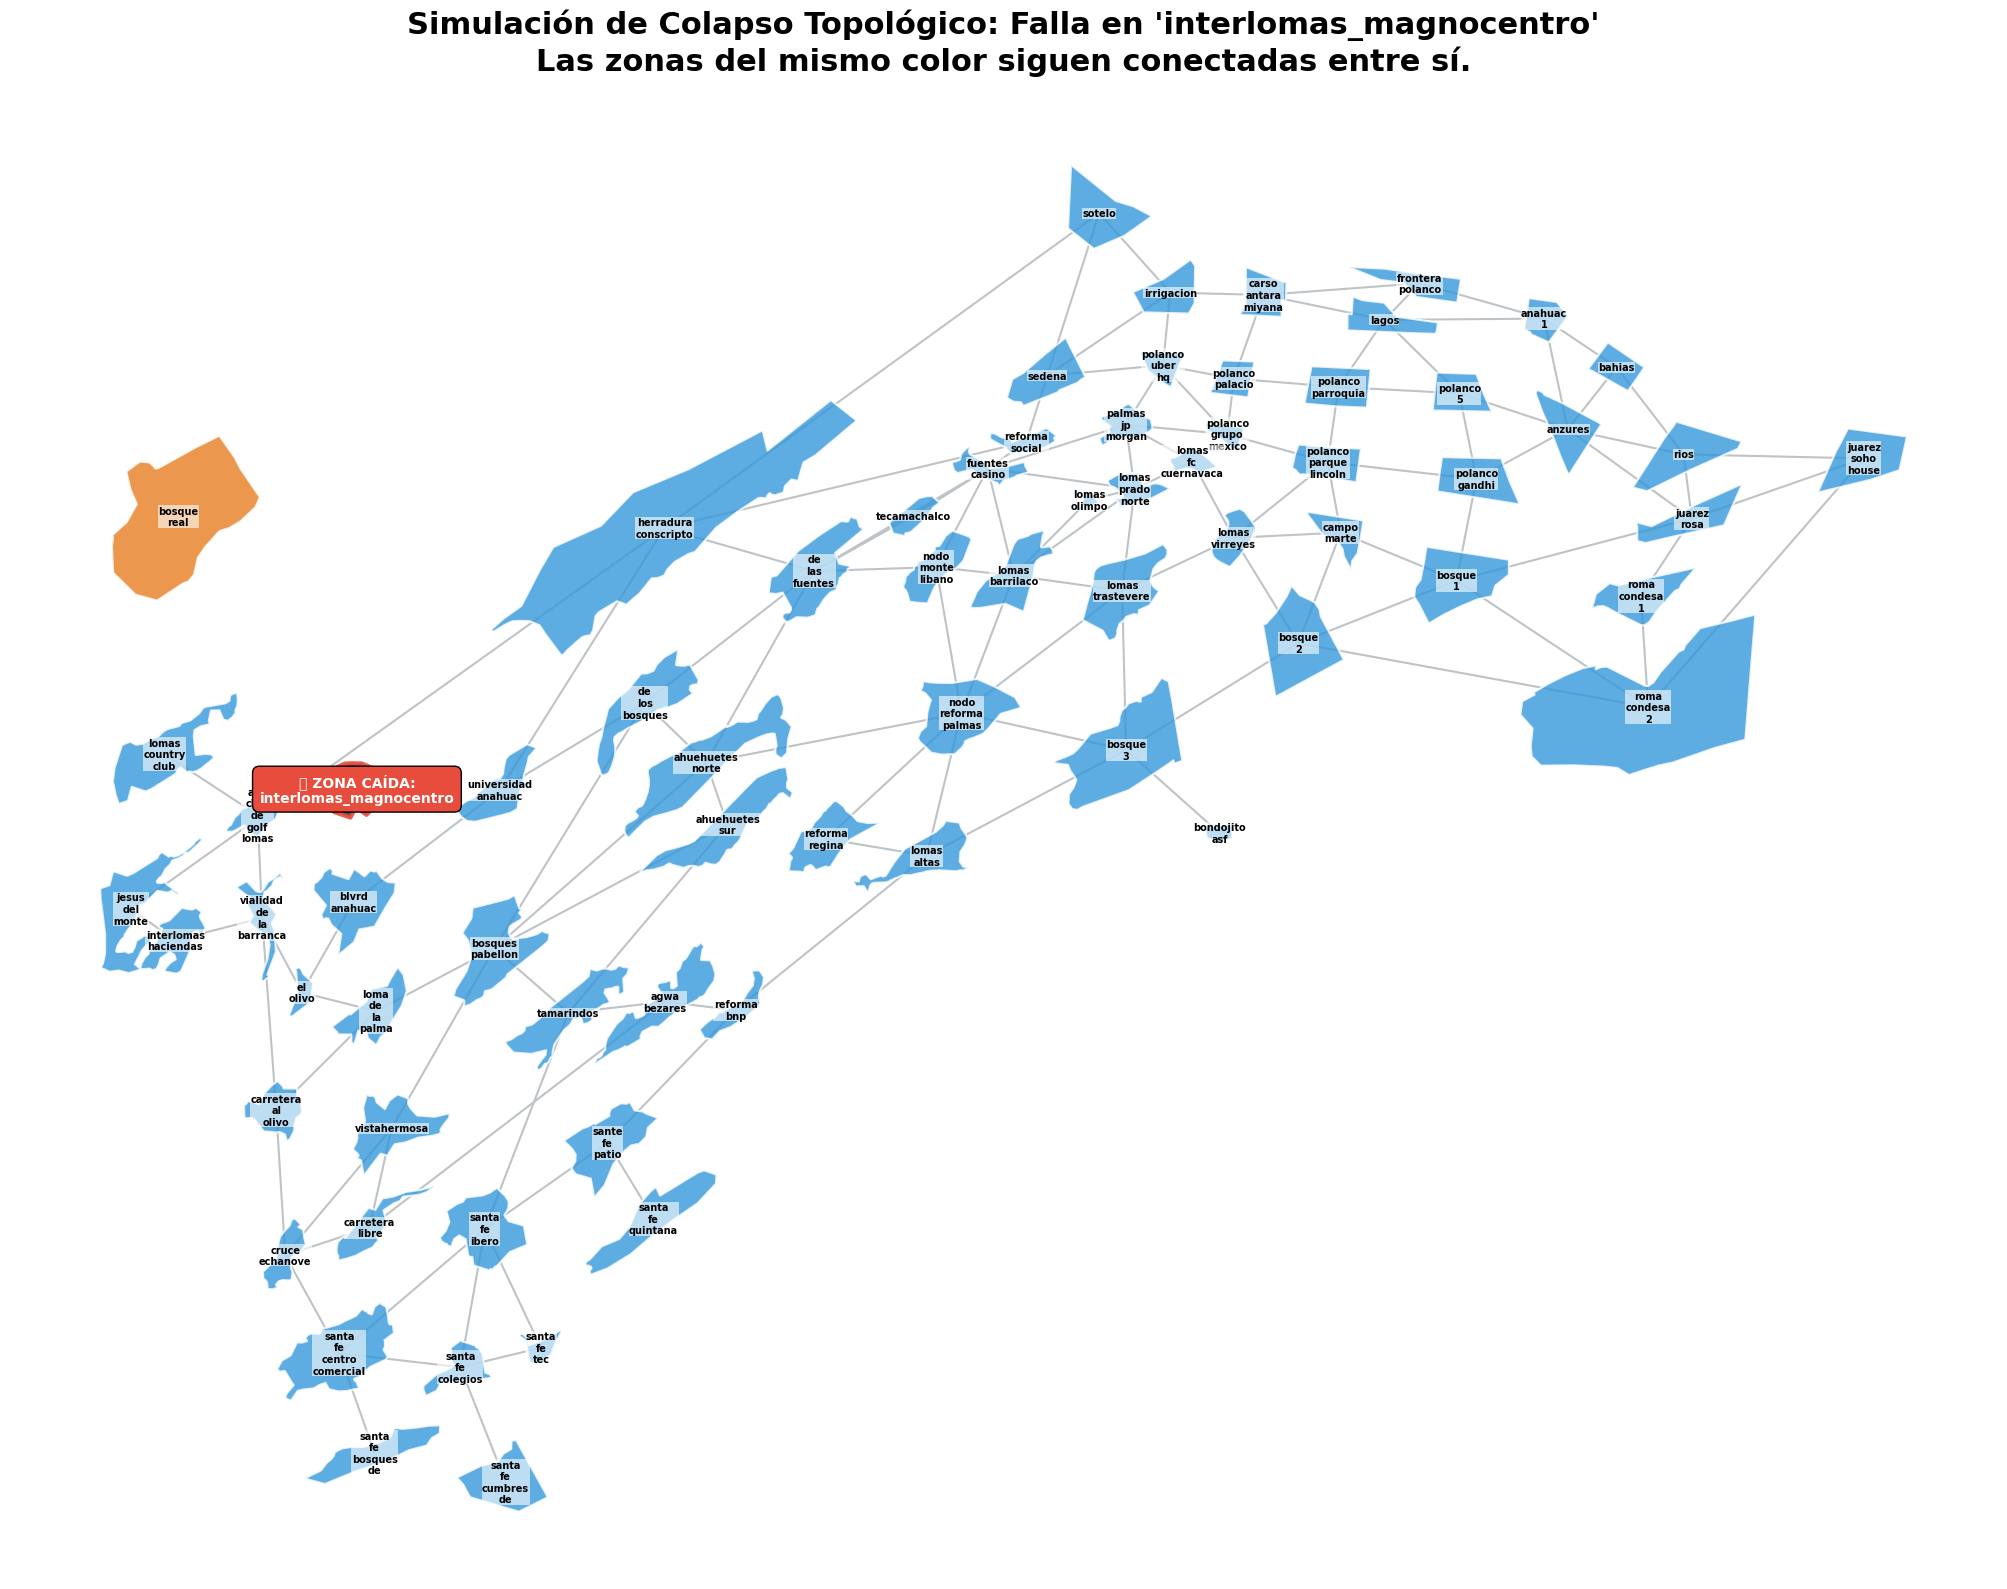

In [10]:
# ==============================================================================
# Cell 2.7: Simulador de Fallas (Análisis de Fragmentación por Nodos Críticos)
# Objetivo: Visualizar las "islas" que se generan al eliminar un Cut-Vertex.
# ==============================================================================

import networkx as nx
import matplotlib.pyplot as plt

print("💥 Iniciando Simulador de Colapso Topológico...")

# --- 1. CONFIGURA TU OBJETIVO AQUÍ ---
# Cámbialo por cualquier nodo de tu lista de Cut-Vertices para ver el impacto
nodo_colapsado = 'interlomas_magnocentro'

if nodo_colapsado not in G_manual.nodes():
    print(f"⚠️ El nodo '{nodo_colapsado}' no existe en la red.")
else:
    # --- 2. SIMULAR LA FALLA ---
    G_sim = G_manual.copy()
    G_sim.remove_node(nodo_colapsado)

    # Calcular las nuevas "Islas" (Componentes Conectados)
    islas = list(nx.connected_components(G_sim))
    # Ordenar las islas por tamaño (la más grande primero)
    islas.sort(key=len, reverse=True)

    print("\n" + "="*70)
    print(f"🚨 REPORTE DE DAÑOS: COLAPSO EN '{nodo_colapsado.upper()}'")
    print("="*70)
    print(f"La red se ha fragmentado en {len(islas)} islas independientes:")

    for i, isla in enumerate(islas):
        tipo = "MACRO-ISLA (Principal)" if i == 0 else f"Micro-Isla {i}"
        print(f"   -> {tipo}: {len(isla)} zonas.")
        if len(isla) <= 5: # Si es pequeña, mostramos quiénes quedaron atrapados
            print(f"      Atrapados: {list(isla)}")

    # --- 3. VISUALIZACIÓN DEL COLAPSO ---
    fig, ax = plt.subplots(figsize=(22, 16))
    ax.set_facecolor('#F8F9F9') # Fondo ligeramente gris

    # Paleta de colores para las islas (La macro isla siempre es Azul, las demás otros colores)
    colores_islas = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6', '#F1C40F']
    pos = nx.get_node_attributes(G_manual, 'schematic_centroid')

    # A. Dibujar las calles sobrevivientes
    for u, v in G_sim.edges():
        if u in pos and v in pos:
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                    color='#BDC3C7', linewidth=1.5, linestyle='-', zorder=1)

    # B. Dibujar las Islas Coloreadas
    gdf_plot = gdf_f.set_geometry('schematic_geometry')

    for i, isla in enumerate(islas):
        color = colores_islas[i % len(colores_islas)]
        # Filtrar polígonos de esta isla
        gdf_isla = gdf_plot[gdf_plot['name'].isin(isla)]
        gdf_isla.plot(ax=ax, facecolor=color, edgecolor='white', linewidth=1.5, alpha=0.8, zorder=2)

        # Etiquetar nodos sobrevivientes
        for zona in isla:
            c = pos[zona]
            ax.text(c[0], c[1], zona.replace('_', '\n'), fontsize=7, fontweight='bold', color='black',
                    ha='center', va='center', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.3), zorder=3)

    # C. Dibujar el Cráter (El nodo colapsado)
    gdf_crater = gdf_plot[gdf_plot['name'] == nodo_colapsado]
    gdf_crater.plot(ax=ax, facecolor='#2C3E50', edgecolor='#E74C3C', linewidth=3, hatch='///', alpha=0.9, zorder=4)

    c_x, c_y = pos[nodo_colapsado]
    ax.text(c_x, c_y, f"❌ ZONA CAÍDA:\n{nodo_colapsado}", color='white', fontsize=10, fontweight='black',
            ha='center', va='center', bbox=dict(facecolor='#E74C3C', alpha=1.0, edgecolor='black', boxstyle='round,pad=0.5'), zorder=5)

    plt.title(f"Simulación de Colapso Topológico: Falla en '{nodo_colapsado}'\nLas zonas del mismo color siguen conectadas entre sí.", fontsize=22, pad=20, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

📏 Calculando Morfología Macro (Límites y Fronteras)...

🌍 REPORTE DE MORFOLOGÍA MACRO (Límites Físicos)
🔸 Densidad de la Red: 0.0532 (Solo existe el 5.3% de las calles posibles)
🔸 Diámetro (Max Distancia): 11 saltos topológicos
🔸 Radio (Min Distancia):    7 saltos topológicos

🎯 EL NÚCLEO ABSOLUTO (Centros):
   - nodo_reforma_palmas
   - fuentes_casino
   - nodo_monte_libano
   - lomas_barrilaco
   - herradura_conscripto
   - de_las_fuentes
   - ahuehuetes_norte
   - tecamachalco

🏕️ LA PERIFERIA EXTREMA (Bordes):
   - rios
   - juarez_rosa
   - juarez_soho_house
   - bahias
   - anahuac_1
   - lagos
   - roma_condesa_1
   - lomas_country_club
   - santa_fe_cumbres_de
   - santa_fe_bosques_de
   - frontera_polanco

🗺️ Renderizando Mapa de Excentricidad (Centro vs Periferia)...


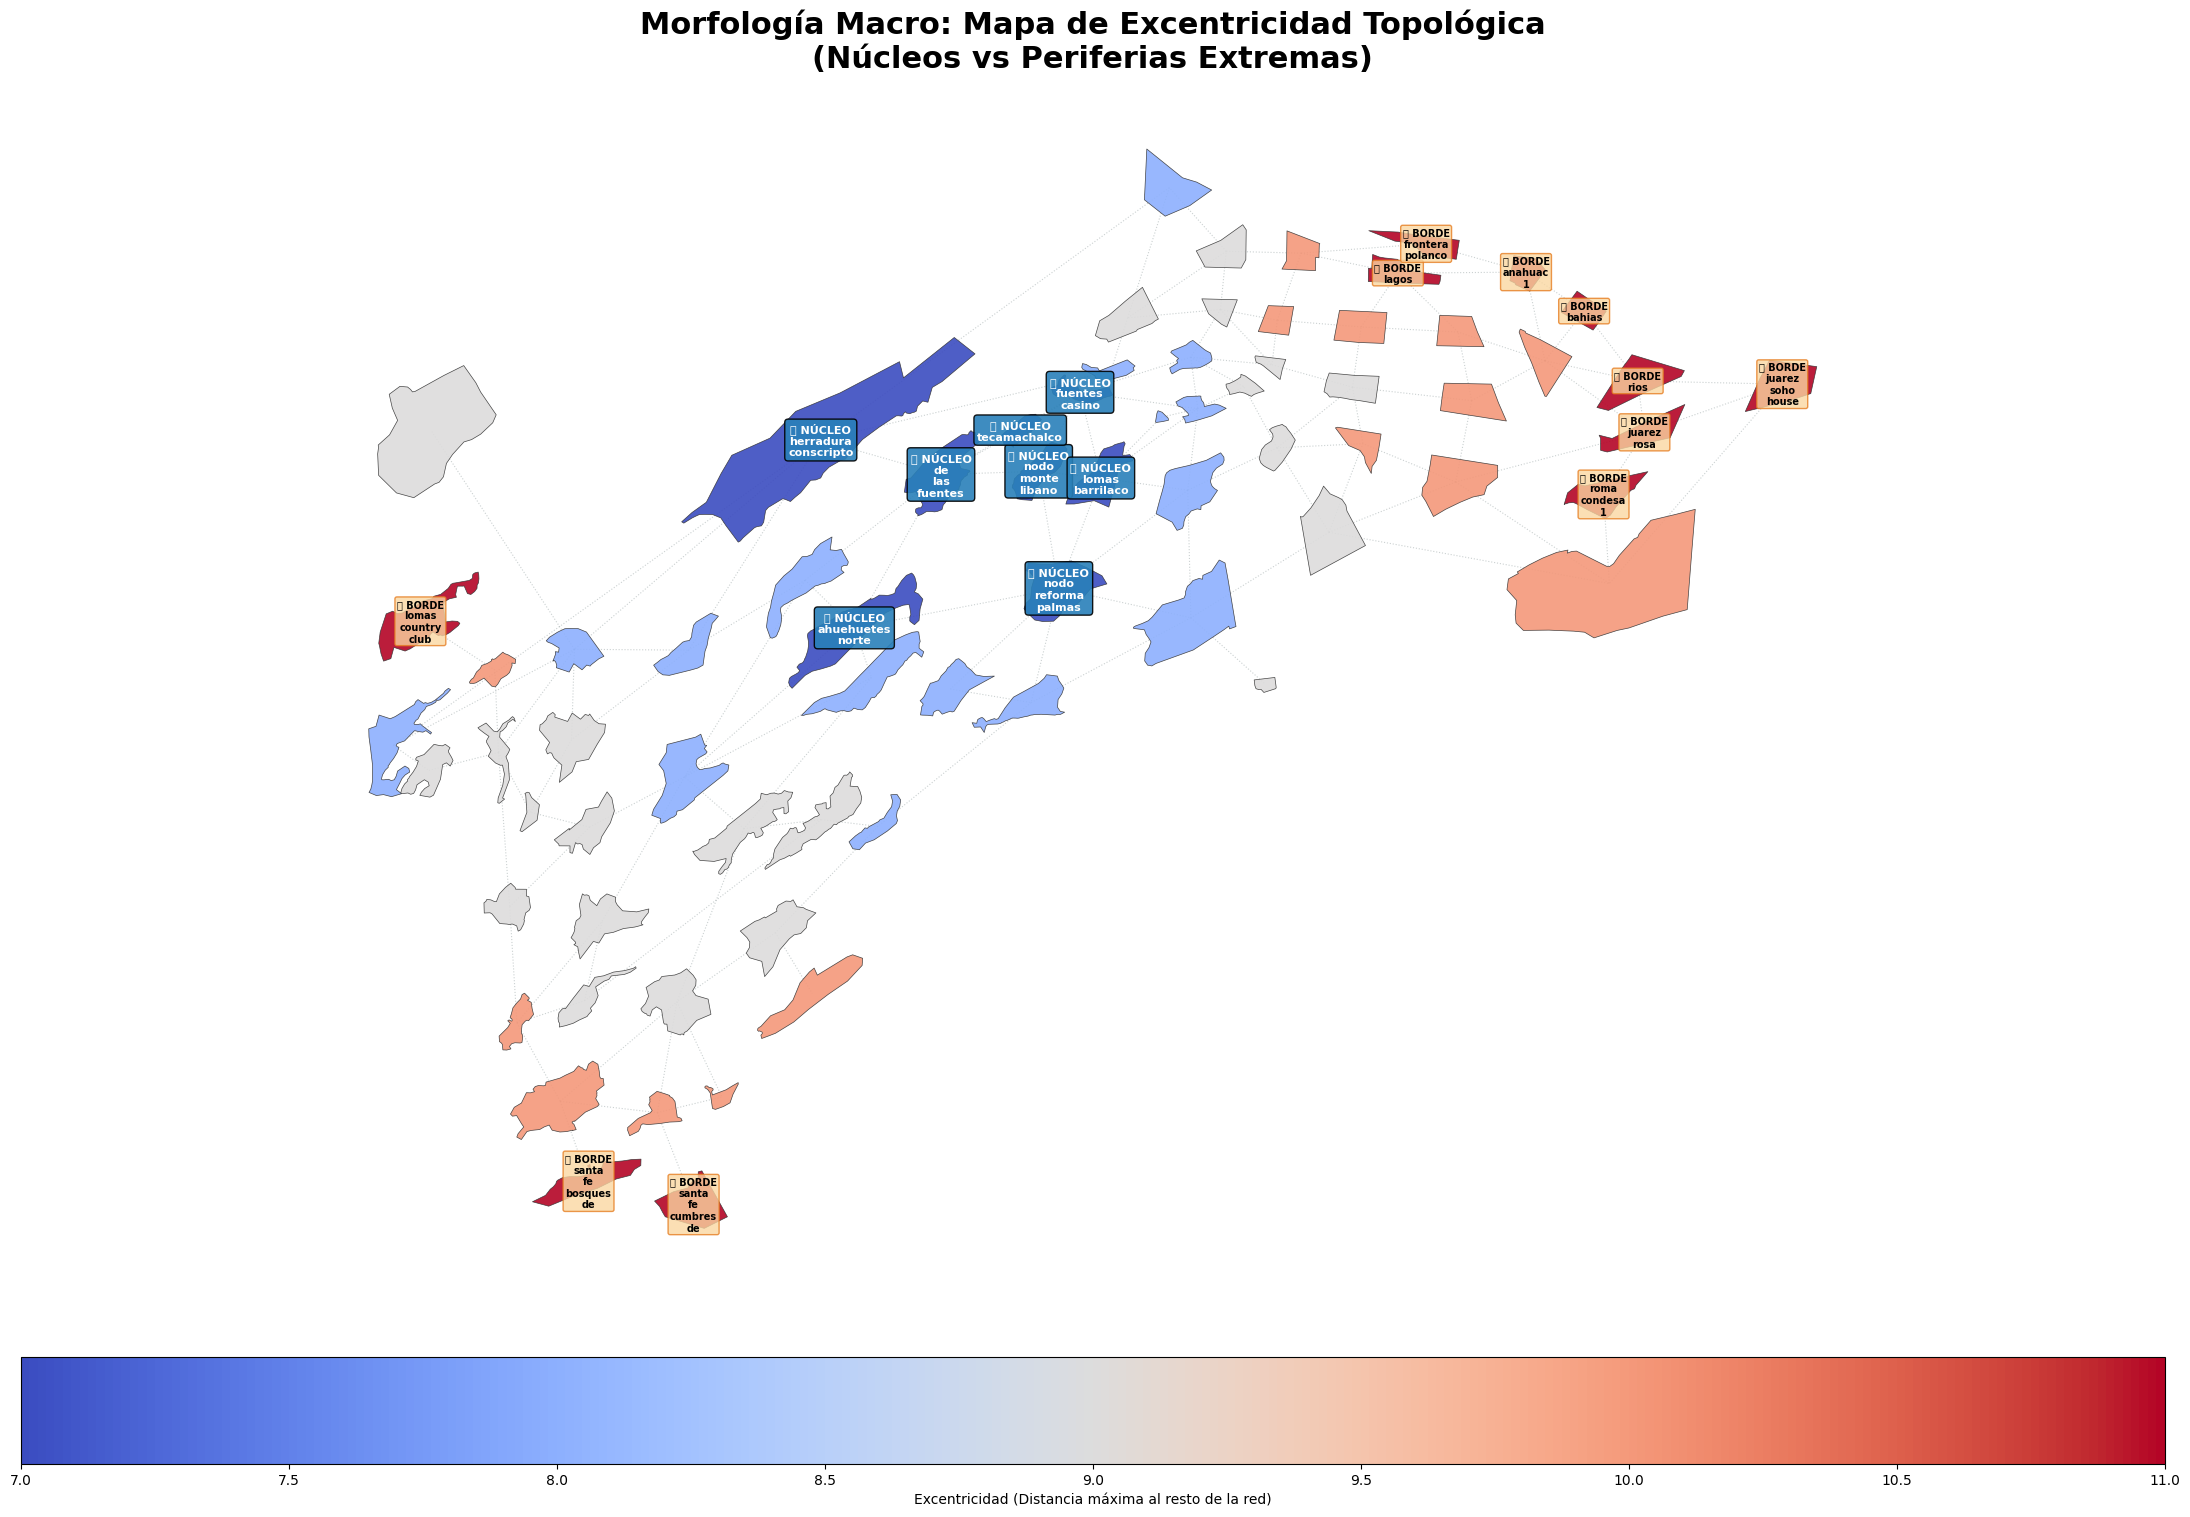

✅ Análisis de Morfología Macro completado.


In [11]:
# ==============================================================================
# Cell 2.8: Morfología Macro (Densidad, Diámetro, Radio y Excentricidad)
# Objetivo: Definir los límites físicos de la red, su centro absoluto y su periferia.
# ==============================================================================

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

print("📏 Calculando Morfología Macro (Límites y Fronteras)...")

# --- 1. EXTRACCIÓN DEL COMPONENTE GIGANTE ---
# Las métricas de distancia máxima fallan si hay nodos inalcanzables (islas).
if not nx.is_connected(G_manual):
    giant_nodes = max(nx.connected_components(G_manual), key=len)
    G_giant = G_manual.subgraph(giant_nodes).copy()
else:
    G_giant = G_manual.copy()

# --- 2. CÁLCULO DE MÉTRICAS GLOBALES ---
# Densidad: % de calles que existen vs las que podrían existir si todos estuvieran conectados con todos.
densidad = nx.density(G_manual)

# Excentricidad: Para cada nodo, ¿cuál es la distancia máxima a cualquier otro nodo?
excentricidad = nx.eccentricity(G_giant)

# Diámetro: La excentricidad máxima de toda la red (El camino más largo posible).
diametro = nx.diameter(G_giant)

# Radio: La excentricidad mínima de toda la red (El camino más corto desde el mejor centro).
radio = nx.radius(G_giant)

# --- 3. CLASIFICACIÓN DE NODOS ---
# Centro: Nodos cuya excentricidad es igual al radio (Los más céntricos)
centros = nx.center(G_giant)

# Periferia: Nodos cuya excentricidad es igual al diámetro (Los más aislados/lejanos)
periferia = nx.periphery(G_giant)

# --- 4. REPORTE EJECUTIVO ---
print("\n" + "="*70)
print("🌍 REPORTE DE MORFOLOGÍA MACRO (Límites Físicos)")
print("="*70)
print(f"🔸 Densidad de la Red: {densidad:.4f} (Solo existe el {densidad*100:.1f}% de las calles posibles)")
print(f"🔸 Diámetro (Max Distancia): {diametro} saltos topológicos")
print(f"🔸 Radio (Min Distancia):    {radio} saltos topológicos")

print(f"\n🎯 EL NÚCLEO ABSOLUTO (Centros):")
for c in centros:
    print(f"   - {c}")

print(f"\n🏕️ LA PERIFERIA EXTREMA (Bordes):")
for p in periferia:
    print(f"   - {p}")

# --- 5. VISUALIZACIÓN ESPACIAL (MAPA DE LEJANÍA / REMOTENESS) ---
print("\n🗺️ Renderizando Mapa de Excentricidad (Centro vs Periferia)...")

# Inyectar métrica al GeoDataFrame
gdf_f['score_eccentricity'] = gdf_f['name'].map(excentricidad)

fig, ax = plt.subplots(figsize=(22, 16))
ax.set_facecolor('white')

# Usamos un colormap donde tonos oscuros/fríos son el Centro (baja excentricidad)
# y tonos cálidos/claros son la Periferia (alta excentricidad).
gdf_plot = gdf_f.set_geometry('schematic_geometry')
gdf_plot.plot(
    column='score_eccentricity',
    ax=ax,
    cmap='coolwarm',
    legend=True,
    legend_kwds={'label': "Excentricidad (Distancia máxima al resto de la red)", 'orientation': "horizontal", 'pad': 0.05},
    alpha=0.9,
    edgecolor='#333333',
    linewidth=0.5,
    zorder=2
)

# Dibujar la red fantasma
pos = nx.get_node_attributes(G_manual, 'schematic_centroid')
for u, v in G_manual.edges():
    if u in pos and v in pos:
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color='#7F8C8D', linewidth=0.8, linestyle=':', alpha=0.4, zorder=1)

# Etiquetar Centros y Periferias
for zona, (x, y) in pos.items():
    if zona in centros:
        ax.text(x, y, f"🎯 NÚCLEO\n{zona.replace('_', '\n')}", color='white', fontsize=8, fontweight='black',
                ha='center', va='center', bbox=dict(facecolor='#2980B9', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.3'), zorder=4)
    elif zona in periferia:
        ax.text(x, y, f"🏕️ BORDE\n{zona.replace('_', '\n')}", color='black', fontsize=7, fontweight='bold',
                ha='center', va='center', bbox=dict(facecolor='#FAD7A1', alpha=0.8, edgecolor='#E67E22', boxstyle='round,pad=0.2'), zorder=3)

plt.title("Morfología Macro: Mapa de Excentricidad Topológica\n(Núcleos vs Periferias Extremas)", fontsize=22, pad=20, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("✅ Análisis de Morfología Macro completado.")

## 📏 Análisis de Morfología Macro: El Espacio Operativo

Este análisis define las fronteras físicas de la plataforma. Al evaluar el grafo desde una perspectiva macro, dejamos de ver nodos individuales y entendemos la "cancha de juego" completa, identificando dónde está el núcleo topológico y dónde están las periferias extremas que generan mayor fricción logística (ETAs altos).

### 1. Dimensiones de la Red
* **Densidad de la Red (5.3%):** De todas las calles y conexiones que podrían existir si cada colonia estuviera conectada directamente con todas las demás, solo existe el 5.3%. Esto es **perfectamente normal y saludable** en redes urbanas (son grafos esparcidos). Refleja una infraestructura real con barreras geográficas, no una cuadrícula teórica.
* **Diámetro (11 Saltos):** Es el viaje con la mayor fricción posible. Para ir del punto A más extremo al punto B más extremo de la ciudad, un conductor tendrá que cruzar obligatoriamente **11 fronteras/zonas**. Este es el límite máximo de ruteo del sistema.
* **Radio (7 Saltos):** Es la distancia desde el "centro absoluto". Si un conductor se para en el núcleo de la ciudad, le tomará como máximo **7 saltos** llegar a la periferia más lejana.

### 2. El Núcleo Absoluto (Centros Topológicos)
Los nodos centrales (`nodo_reforma_palmas`, `tecamachalco`, `herradura_conscripto`, etc.) no son necesariamente el centro *geográfico* (en coordenadas X/Y), sino el **centro topológico**.
Forman un "cinturón" estratégico que actúa como bisagra entre dos mundos muy separados: el oriente (Polanco, Roma, Juárez) y el poniente profundo (Santa Fe, Interlomas). Posicionar oferta (conductores) en este núcleo garantiza el menor tiempo de respuesta promedio hacia cualquier solicitud que caiga en el mapa.

### 3. La Periferia Extrema (Bordes)
Las zonas periféricas (`juarez_rosa`, `lomas_country_club`, `santa_fe_bosques_de`, etc.) son las puntas del grafo. Operativamente, estos son **"sumideros logísticos"**. Si un conductor entra aquí a dejar un viaje, le tomará demasiado esfuerzo (hasta 11 saltos) regresar al otro extremo de la ciudad, lo que justifica la necesidad de tarifas dinámicas o algoritmos de reubicación para no perder eficiencia en la plataforma.

#### **Clarificando excentricidad**

Sí, la excentricidad es un número, pero no es un número global de la red, sino un número individual para CADA nodo. Piénsalo así:

Excentricidad de una colonia: Es la respuesta a la pregunta: "Si estoy parado en esta colonia, ¿cuántos saltos me toma llegar al rincón más alejado de TODO el mapa?"

La excentricidad de herradura_conscripto es 7 (porque desde ahí, lo más lejos está a 7 saltos).

La excentricidad de lomas_country_club es 11 (porque desde ahí, lo más lejos está a 11 saltos).

Como cada colonia tiene su propio número de excentricidad, de ahí sacamos las métricas globales:

Radio (7): Es simplemente la excentricidad más pequeña de toda la red. Las colonias que sacan este número ganador conforman el "Núcleo".

Diámetro (11): Es la excentricidad más grande de toda la red. Las colonias que sacan esta peor calificación conforman la "Periferia Extrema".

🧩 Ejecutando algoritmo de modularidad para detectar Estructura Latente...

🏘️ REPORTE: 6 MACRO-ZONAS ORGÁNICAS DETECTADAS

🔹 Comunidad 0 (18 zonas):
   anahuac_1, anzures, bahias, bosque_1, bosque_2, campo_marte, frontera_polanco, juarez_rosa, juarez_soho_house, lagos, lomas_virreyes, polanco_5, polanco_gandhi, polanco_parque_lincoln, polanco_parroquia, rios, roma_condesa_1, roma_condesa_2

🔹 Comunidad 1 (13 zonas):
   bondojito_asf, bosque_3, fuentes_casino, lomas_altas, lomas_barrilaco, lomas_fc_cuernavaca, lomas_olimpo, lomas_prado_norte, lomas_trastevere, nodo_monte_libano, nodo_reforma_palmas, palmas_jp_morgan, reforma_regina

🔹 Comunidad 2 (13 zonas):
   agwa_bezares, carretera_libre, cruce_echanove, reforma_bnp, santa_fe_bosques_de, santa_fe_centro_comercial, santa_fe_colegios, santa_fe_cumbres_de, santa_fe_ibero, santa_fe_quintana, santa_fe_tec, sante_fe_patio, vistahermosa

🔹 Comunidad 3 (12 zonas):
   ave_club_de_golf_lomas, blvrd_anahuac, bosque_real, carretera_al_olivo, el_

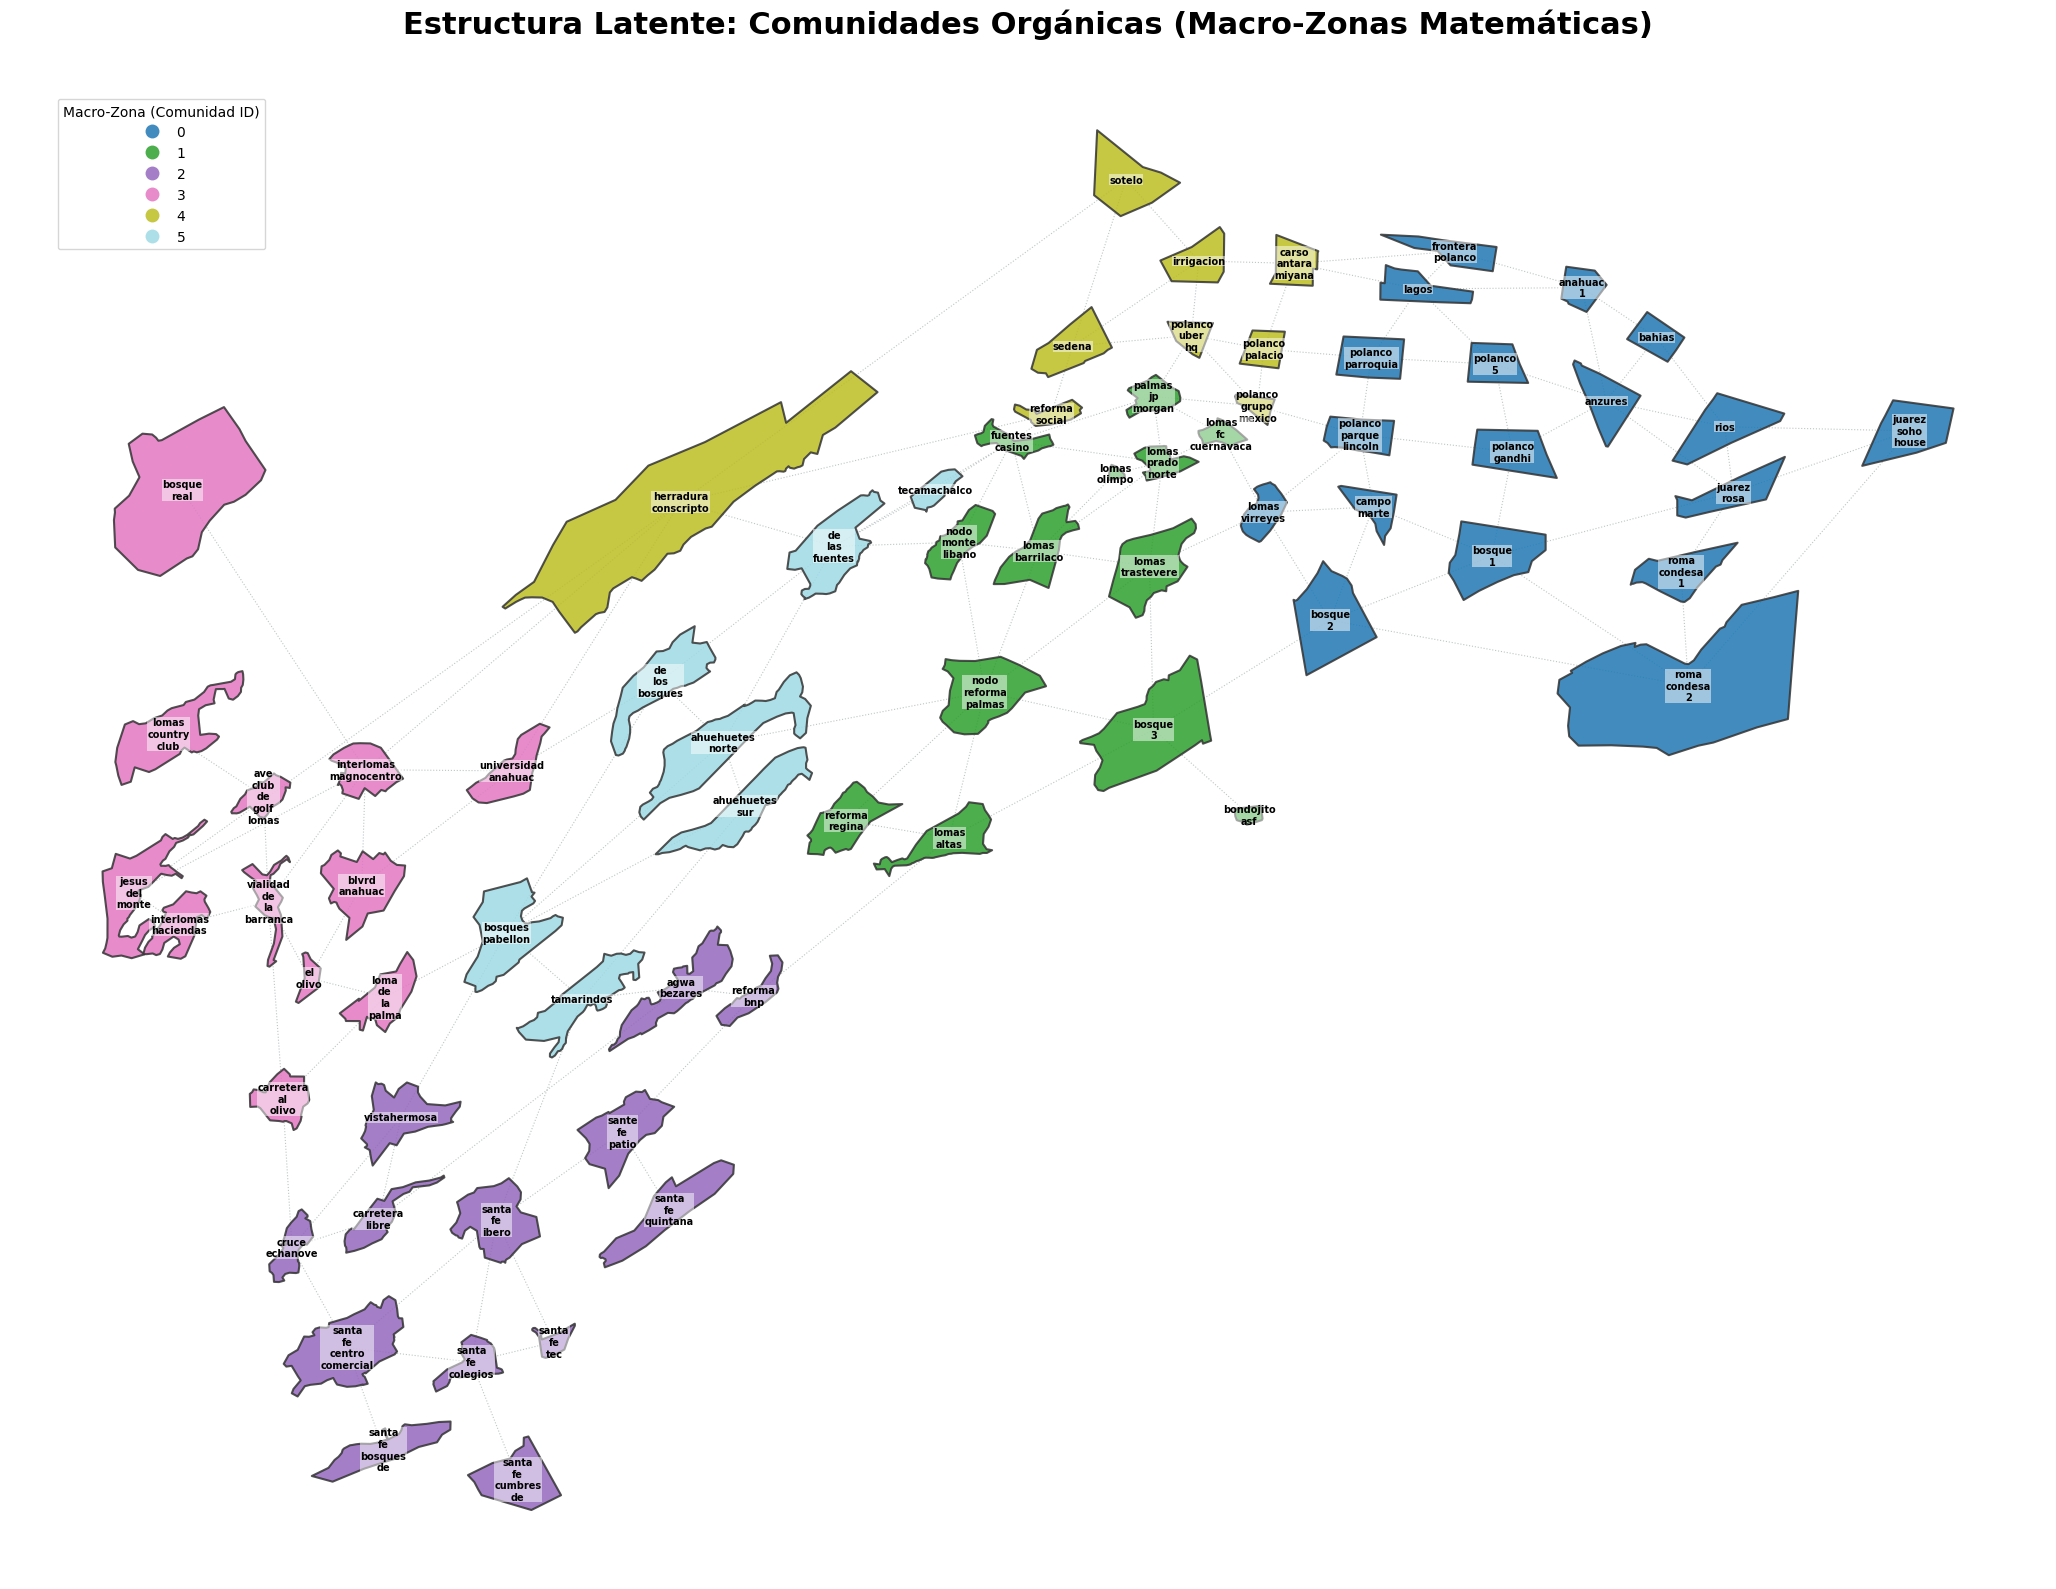

✅ Análisis de Comunidades completado. ¡Bloque No Dirigido 100% CERRADO!


In [12]:
# ==============================================================================
# Cell 2.9: Estructura Latente (Detección de Comunidades Orgánicas)
# Objetivo: Identificar macro-zonas matemáticas basadas en la densidad de calles.
# ==============================================================================

import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
import matplotlib.pyplot as plt
import pandas as pd

print("🧩 Ejecutando algoritmo de modularidad para detectar Estructura Latente...")

# --- 1. DETECCIÓN DE COMUNIDADES ---
# El algoritmo agrupa nodos densamente conectados entre sí, maximizando la modularidad
comunidades = list(greedy_modularity_communities(G_manual))

# --- 2. MAPEO AL GRAFO Y GEODATAFRAME ---
community_map = {}
for i, comm in enumerate(comunidades):
    for nodo in comm:
        community_map[nodo] = i

# Inyectamos el ID de la comunidad al grafo y al dataframe espacial
nx.set_node_attributes(G_manual, community_map, 'community_id')
gdf_f['community_id'] = gdf_f['name'].map(community_map)

# --- 3. REPORTE EJECUTIVO ---
print("\n" + "="*70)
print(f"🏘️ REPORTE: {len(comunidades)} MACRO-ZONAS ORGÁNICAS DETECTADAS")
print("="*70)

for i, comm in enumerate(comunidades):
    print(f"\n🔹 Comunidad {i} ({len(comm)} zonas):")
    print("   " + ", ".join(sorted(list(comm))))

# --- 4. VISUALIZACIÓN ESPACIAL ---
print("\n🗺️ Renderizando Mapa de Comunidades...")

fig, ax = plt.subplots(figsize=(22, 16))
ax.set_facecolor('white')

# Usamos 'tab20' que es una paleta categórica excelente para diferenciar muchos grupos distintos
gdf_plot = gdf_f.set_geometry('schematic_geometry')
gdf_plot.plot(
    column='community_id',
    ax=ax,
    cmap='tab20',
    edgecolor='#333333',
    linewidth=1.5,
    alpha=0.85,
    zorder=2,
    categorical=True,
    legend=True,
    legend_kwds={'title': "Macro-Zona (Comunidad ID)", 'loc': 'upper left', 'bbox_to_anchor': (0.02, 0.98), 'fontsize': 10}
)

# Dibujar conexiones tenues para no robar atención al color
pos = nx.get_node_attributes(G_manual, 'schematic_centroid')
for u, v in G_manual.edges():
    if u in pos and v in pos:
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color='#7F8C8D', linewidth=0.8, linestyle=':', alpha=0.5, zorder=1)

# Etiquetar nodos
for zona, (x, y) in pos.items():
    ax.text(x, y, zona.replace('_', '\n'), color='black', fontsize=7, fontweight='bold',
            ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.3), zorder=3)

plt.title("Estructura Latente: Comunidades Orgánicas (Macro-Zonas Matemáticas)", fontsize=22, pad=20, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("✅ Análisis de Comunidades completado. ¡Bloque No Dirigido 100% CERRADO!")

# Puente de Datos

In [46]:
# ==============================================================================
# Cell 4.1: El Puente Soberano (Integración BigQuery - Solo Destinos en Mini)
# Objetivo: Cargar Flujo OD (GAN) y Censo de Resolución (Weights).
# ==============================================================================

import networkx as nx
import pandas as pd
from google.cloud import bigquery
import google.auth

print("🔌 Conectando al Puente Soberano: BigQuery Edition (Censo de Destinos)...")

# --- 1. CONFIGURACIÓN DE CLIENTE Y GRAFO ---
try:
    credentials, project = google.auth.default()
    client = bigquery.Client(credentials=credentials, project=PROJECT_ID)
    print(f"✅ Conectado a BigQuery: {PROJECT_ID}")
except Exception as e:
    print(f"🔴 ERROR DE AUTH: {e}")
    raise

# Evolución a DiGraph (Vectores de flujo para ruteo)
G_dir = G_manual.to_directed()
for u, v in G_dir.edges():
    G_dir[u][v]['volume_flow'] = 0
    G_dir[u][v]['financial_flow'] = 0.0

print(f"✅ Grafo Dirigido inicializado: {G_dir.number_of_nodes()} zonas.")

# --- 2. DESCARGA DEL MANIFOLD SINTÉTICO (Flujo OD - pienza_big) ---
print("\n📡 1/2 Descargando Manifold Enriquecido (Origen -> Destino)...")
query_gan = f"""
    SELECT
        pickup_name as origin,  -- <--- AGREGADO EL ALIAS 'as origin' AQUÍ
        dropoff_name as destination,
        upfront_fare,
        hour_of_day
    FROM `{PROJECT_ID}.{DATASET_BIG}.synthetic_manifold_v8_enriched`
"""
df_synthetic = client.query(query_gan).to_dataframe()

# Sanitización básica
df_synthetic['origin'] = df_synthetic['origin'].str.strip().str.lower()
df_synthetic['destination'] = df_synthetic['destination'].str.strip().str.lower()
print(f"   ✅ GAN Manifold cargado: {len(df_synthetic):,} viajes sintéticos.")

# --- 3. DESCARGA DEL CENSO DE PESOS (Resolución Micro - pienza_mini) ---
print("📡 2/2 Descargando Censo de Destinos (silver_palette)...")

query_weights = f"""
    SELECT
        dropoff_polygon_name as micro_name,
        COUNT(*) as hist_trips
    FROM `{PROJECT_ID}.{DATASET_CORE}.silver_palette`
    WHERE dropoff_polygon_name IS NOT NULL
    GROUP BY 1
"""
df_micro_weights = client.query(query_weights).to_dataframe()
df_micro_weights['micro_name'] = df_micro_weights['micro_name'].str.strip().str.lower()
print(f"   ✅ Censo Micro-Zonas cargado: {len(df_micro_weights)} polígonos con data real.")

# --- 4. ENSAMBLAJE DE LA MATRIZ OD MAESTRA (df_gan_matrix) ---
print("\n⚙️  Ensamblando Matriz OD Final para Downscaling...")

# Agrupamos el GAN para tener el volumen macro
df_gan_matrix = df_synthetic.groupby(['origin', 'destination']).agg(
    gan_volume=('upfront_fare', 'count'),
    gan_avg_fare=('upfront_fare', 'mean')
).reset_index()

df_gan_matrix['avg_upfront_fare'] = df_gan_matrix['gan_avg_fare']

print(f"✅ Matriz OD preparada: {len(df_gan_matrix):,} pares únicos.")
display(df_gan_matrix.head(5))

🔌 Conectando al Puente Soberano: BigQuery Edition (Censo de Destinos)...
✅ Conectado a BigQuery: 645009831643
✅ Grafo Dirigido inicializado: 72 zonas.

📡 1/2 Descargando Manifold Enriquecido (Origen -> Destino)...
   ✅ GAN Manifold cargado: 1,010,001 viajes sintéticos.
📡 2/2 Descargando Censo de Destinos (silver_palette)...
   ✅ Censo Micro-Zonas cargado: 72 polígonos con data real.

⚙️  Ensamblando Matriz OD Final para Downscaling...
✅ Matriz OD preparada: 1,242 pares únicos.


,origin,destination,gan_volume,gan_avg_fare,avg_upfront_fare
0,agwa_bezares__reforma_bnp,agwa_bezares__reforma_bnp,190,81.623389,81.623389
1,agwa_bezares__reforma_bnp,ahuehuetes_sur,401,70.709385,70.709385
2,agwa_bezares__reforma_bnp,barranca_del_muerto,189,163.404340,163.404340
3,agwa_bezares__reforma_bnp,carretera_al_olivo__carretera_libre__cruce_ech...,400,36.064212,36.064212
4,agwa_bezares__reforma_bnp,cruce_echanove,391,70.882255,70.882255


In [47]:
# ==============================================================================
# Cell 4.3: Descarga y Verificación del Manifold Enriquecido (Vía BigQuery)
# Objetivo: Traer la tabla que YA ESTÁ desnormalizada desde Pienza Big.
# ==============================================================================
import pandas as pd
from google.cloud import bigquery
import google.auth

print("🚀 CONECTANDO A LA BÓVEDA ENRIQUECIDA (SPARK -> BIGQUERY -> COLAB)")
print("-" * 75)

# --- 1. AUTENTICACIÓN Y CONEXIÓN ---
try:
    credentials, project = google.auth.default()
    # Usamos el proyecto donde guardaste la tabla grande
    client = bigquery.Client(credentials=credentials, project='drivers-dilemma')
    print("✅ Conectado a BigQuery (drivers-dilemma).")
except Exception as e:
    print(f"🔴 ERROR DE AUTH: {e}")
    raise

# --- 2. DESCARGA DIRECTA Y FILTRO ENDÓGENO ---
print("📡 Descargando el millón de viajes (Omitiendo 'unassigned_area')...")

# Hacemos el query directo a tu tabla enriquecida.
# De paso, filtramos la basura externa para no saturar la RAM de Colab.
query_manifold = """
    SELECT
        CAST(hour_of_day AS INT64) as hour_of_day,
        pickup_name,
        dropoff_name,
        upfront_fare
    FROM `drivers-dilemma.pienza_big.synthetic_manifold_v8_enriched`
"""

df_synthetic = client.query(query_manifold).to_dataframe()

print(f"   ✅ Descarga completada: {len(df_synthetic):,} viajes endógenos listos para ruteo.")
print("-" * 75)

# --- 3. AUDITORÍA DE VOLUMEN TOTAL ---
print("\nTop 10 Zonas de Origen (Nombres Reales desde BigQuery):")
display(df_synthetic['pickup_name'].value_counts().head(10))
print("-" * 75)

🚀 CONECTANDO A LA BÓVEDA ENRIQUECIDA (SPARK -> BIGQUERY -> COLAB)
---------------------------------------------------------------------------
✅ Conectado a BigQuery (drivers-dilemma).
📡 Descargando el millón de viajes (Omitiendo 'unassigned_area')...
   ✅ Descarga completada: 1,010,001 viajes endógenos listos para ruteo.
---------------------------------------------------------------------------

Top 10 Zonas de Origen (Nombres Reales desde BigQuery):


,count
pickup_name,
unassigned_area,225481
anzures,69333
rios,52363
santa_fe_centro_comercial,49915
tamarindos,49129
santa_fe_ibero,41912
anahuac_1__bahias__frontera_polanco,38298
ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,35697
roma_condesa_2,31197


---------------------------------------------------------------------------


In [54]:
# ==============================================================================
# Cell 4.2: Inyección de Inteligencia GAN (Downscaling Semántico)
# Objetivo: Repartir el volumen del GAN usando el mapeo Micro:unassigned -> Macro:unassigned_area
# ==============================================================================
import pandas as pd
import numpy as np

print("⚖️ Iniciando Downscaling sobre el Manifold Sintético...")

# --- 1. RECUPERAR CENSO REAL DESDE BIGQUERY ---
query_counts = f"SELECT dropoff_polygon_name as micro_name, count(*) as hist_trips FROM `{PROJECT_ID}.{DATASET_CORE}`.v_ML_Supervised GROUP BY 1"
micro_counts = client.query(query_counts).to_dataframe()
micro_counts['micro_name'] = micro_counts['micro_name'].str.strip().str.lower()

# --- 2. CONSTRUIR LA ROSETTA (Micro -> Macro Semántico) ---
rosetta_data = []
for idx, row in gdf_nodes.iterrows():
    m_id = id_map.get(idx, -1)
    if m_id >= 0:
        p_id = f"P_{m_id}"
        rosetta_data.append({
            'micro_name': row['name'].strip().lower(),
            'macro_name': salchichota_names.get(p_id, 'Unknown').strip().lower()
        })

# LA TRADUCCIÓN CORRECTA:
# Micro (Realidad) se llama 'unassigned'
# Macro (GAN) se llama 'unassigned_area'
rosetta_data.append({'micro_name': 'unassigned', 'macro_name': 'unassigned_area'})
df_rosetta = pd.DataFrame(rosetta_data)

# Unir con conteos reales y calcular pesos
df_rosetta = df_rosetta.merge(micro_counts, on='micro_name', how='left').fillna(0)
df_rosetta['macro_total_hist'] = df_rosetta.groupby('macro_name')['hist_trips'].transform('sum')
df_rosetta['historical_weight'] = np.where(
    df_rosetta['macro_total_hist'] > 0,
    df_rosetta['hist_trips'] / df_rosetta['macro_total_hist'],
    0
)

# --- 3. DOWNSCALING (Cruce con el volumen del GAN) ---
gan_stats = df_synthetic.groupby('pickup_name').size().reset_index(name='gan_total_demand')
gan_stats['pickup_name'] = gan_stats['pickup_name'].str.strip().str.lower()

# Cruce: macro_name ('unassigned_area') vs. pickup_name ('unassigned_area')
bridge = pd.merge(df_rosetta, gan_stats, left_on='macro_name', right_on='pickup_name', how='left').fillna(0)
bridge['micro_gan_demand'] = bridge['gan_total_demand'] * bridge['historical_weight']

# Inyección final
dict_demand = bridge.set_index('micro_name')['micro_gan_demand'].to_dict()
gdf_f['gan_demand'] = gdf_f['name'].map(dict_demand).fillna(0)

print(f"✅ Downscaling completado. {len(bridge)} zonas procesadas.")

⚖️ Iniciando Downscaling sobre el Manifold Sintético...
✅ Downscaling completado. 73 zonas procesadas.


In [58]:
# ==============================================================================
# Cell 4.4 (ULTRA-FIX): Auditoría de Fidelidad 100% Alineada
# Objetivo: Garantizar paridad 1:1 ignorando discrepancias de formato/espacios.
# ==============================================================================
import pandas as pd

print("📋 GENERANDO TABLA MAESTRA DE FIDELIDAD (MODO ROBUSTO)...")

# --- 1. PREPARAR REALIDAD ---
df_real_final = micro_counts.copy()
# Normalización agresiva
df_real_final['micro_name'] = df_real_final['micro_name'].astype(str).str.strip().str.lower()
# Estandarización de nombres
df_real_final['micro_name'] = df_real_final['micro_name'].replace('unassigned', 'unassigned_area')

total_real = df_real_final['hist_trips'].sum()
df_real_final['share_real'] = (df_real_final['hist_trips'] / total_real) * 100

# --- 2. PREPARAR SINTÉTICO (El Downscaling) ---
df_synth_final = bridge[['micro_name', 'micro_gan_demand']].copy()
df_synth_final['micro_name'] = df_synth_final['micro_name'].astype(str).str.strip().str.lower()

# ¡AQUÍ ESTABA EL ERROR! Faltaba alinear el lado sintético para que hagan match en la misma fila
df_synth_final['micro_name'] = df_synth_final['micro_name'].replace('unassigned', 'unassigned_area')

# Agrupamos por si el reemplazo generó duplicados
df_synth_final = df_synth_final.groupby('micro_name')['micro_gan_demand'].sum().reset_index()

total_synth = df_synth_final['micro_gan_demand'].sum()
# Protección contra división por cero
if total_synth > 0:
    df_synth_final['share_synth'] = (df_synth_final['micro_gan_demand'] / total_synth) * 100
else:
    df_synth_final['share_synth'] = 0

# --- 3. MERGE FINAL (Cruce de Caminos) ---
all_names = sorted(list(set(df_real_final['micro_name']) | set(df_synth_final['micro_name'])))
df_master_list = pd.DataFrame({'micro_name': all_names})

df_audit_full = pd.merge(df_master_list, df_real_final[['micro_name', 'share_real']], on='micro_name', how='left')
df_audit_full = pd.merge(df_audit_full, df_synth_final[['micro_name', 'share_synth']], on='micro_name', how='left')

df_audit_full = df_audit_full.fillna(0)
df_audit_full['delta_abs'] = df_audit_full['share_synth'] - df_audit_full['share_real']

# --- 4. FORMATO DE VISUALIZACIÓN ---
df_styled = df_audit_full.copy()
df_styled['share_real'] = df_styled['share_real'].map('{:.4f} %'.format)
df_styled['share_synth'] = df_styled['share_synth'].map('{:.4f} %'.format)
df_styled['delta_abs'] = df_styled['delta_abs'].map('{:+.4f} %'.format)

# --- 5. REPORTE FINAL ---
print(f"\n✅ AUDITORÍA FINALIZADA (Base: {total_real:,.0f} reales vs {total_synth:,.0f} sintéticos):")
print("-" * 85)
display(df_styled[['micro_name', 'share_real', 'share_synth', 'delta_abs']])

# MAE Global
mae_final = df_audit_full['delta_abs'].abs().mean()
print("-" * 85)
print(f"🏆 Mean Absolute Error (MAE) Global: {mae_final:.6f} %")

📋 GENERANDO TABLA MAESTRA DE FIDELIDAD (MODO ROBUSTO)...

✅ AUDITORÍA FINALIZADA (Base: 4,765 reales vs 663,770 sintéticos):
-------------------------------------------------------------------------------------


,micro_name,share_real,share_synth,delta_abs
0,agwa_bezares,0.3987 %,0.0000 %,-0.3987 %
1,ahuehuetes_norte,0.3987 %,0.0000 %,-0.3987 %
2,ahuehuetes_sur,1.0073 %,2.4567 %,+1.4494 %
3,anahuac_1,0.5037 %,0.0000 %,-0.5037 %
4,anzures,1.0073 %,10.4453 %,+9.4380 %
5,ave_club_de_golf_lomas,0.0630 %,0.0000 %,-0.0630 %
6,bahias,0.3148 %,0.0000 %,-0.3148 %
7,blvrd_anahuac,0.2518 %,0.0000 %,-0.2518 %
8,bondojito_asf,0.2728 %,0.0000 %,-0.2728 %
9,bosque_1,0.0839 %,0.0000 %,-0.0839 %


-------------------------------------------------------------------------------------
🏆 Mean Absolute Error (MAE) Global: 1.026692 %


In [36]:
# ==============================================================================
# Cell 4.7: Olimpo Survival Audit (Downscaling Threshold)
# Objetivo: Ver si la repartición matemática le asignó vida sintética a Olimpo.
# ==============================================================================

ZONA_MICRO = 'lomas_olimpo'

print(f"⚖️ Verificando el 'reparto de herencia' para {ZONA_MICRO}...")

# 1. Extraer los datos del bridge (Celda 4.2)
olimpo_data = bridge[bridge['micro_name'] == ZONA_MICRO]

if not olimpo_data.empty:
    macro_id = olimpo_data['macro_p_id'].values[0]
    hist_micro = olimpo_data['hist_trips'].values[0]
    peso = olimpo_data['historical_weight'].values[0]
    gan_total_macro = olimpo_data['gan_total_demand'].values[0]
    synth_micro = olimpo_data['micro_gan_demand'].values[0]

    print("-" * 60)
    print(f"📍 Macro-Zona Perteneciente:       {macro_id}")
    print(f"📊 Viajes Reales (Mini):           {hist_micro}")
    print(f"🎯 Peso s/ Macro-Zona:             {peso:.6f} ({peso*100:.4f}%)")
    print(f"🎲 Viajes Totales GAN en {macro_id}: {gan_total_macro:,.0f}")
    print("-" * 60)
    print(f"🔮 RESULTADO DEL DOWNSCALING:      {synth_micro:.2f} viajes sintéticos")
    print("-" * 60)

    if synth_micro >= 1.0:
        print(f"✅ ¡SOBREVIVIÓ! El GAN generó suficiente volumen para que le tocaran {int(synth_micro)} viajes.")
    else:
        print(f"⚠️ MURIÓ EN EL REDONDEO: El volumen de la Macro-Zona no fue suficiente para alcanzar 1 viaje.")
        print(f"   Necesitarías que el GAN generara al menos {1/peso:,.0f} viajes en {macro_id} para que Olimpo tenga 1.")
else:
    print(f"❌ ERROR: No se encontró la zona {ZONA_MICRO} en el proceso de Downscaling.")

⚖️ Verificando el 'reparto de herencia' para lomas_olimpo...


KeyError: 'macro_p_id'